<a href="https://colab.research.google.com/github/adamszmatula/Malaria-Detection/blob/main/Malaria_Detection_Full_Code_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Malaria Detection**

## <b>Executive Summary </b>

This project developed an automated deep learning model to classify red blood cell microscopy images as parasitized or uninfected, addressing a global malaria burden of 282 million cases and 610,000 deaths in 2024.

Five CNN models were built and compared, progressively introducing deeper architectures, BatchNormalization, LeakyReLU and data augmentation. The final selected model (Model 3) uses a double convolutional block architecture trained on augmented images with random rotations, flips and zoom, achieving a test accuracy of 98.81% and a recall of 0.99 on the parasitized class - only 7 false negatives out of 1,300 infected cells, the best result of all five models.

At 4.28 MB for a total of 1,121,426 parameters, the model is lightweight enough for deployment on basic field equipment in resource-limited endemic regions.

Before clinical use, validation on independent datasets from different microscopes, laboratories and geographic regions is required, particularly in the Democratic Republic of the Congo, Ethiopia, Mozambique, Nigeria and Uganda, which together account for more than half of all global malaria cases.

---
> ⚠️ **Disclaimer**
>
> *All epidemiological data statistics and figures cited in the Executive Summary, Problem Definition and Risks and Challenges sections of this notebook are sourced from the World Health Organization's World Malaria Report 2025.*
---



##<b>Problem Definition</b>
**The context:** Malaria is a life-threatening disease caused by Plasmodium parasites responsible for over 282 million cases and 61,000 deaths worldwide in 2024 alone, with children under 5 being the most vulnerable group accounting for 75% of all malaria deaths. Traditional laboratory diagnosis relies on manual inspection of blood smears by trained experts, a process that is tedious, time-consuming and prone to errors - making early and accurate detection at scale, particularly in resource-limited regions where the disease is most prevalent.<br>

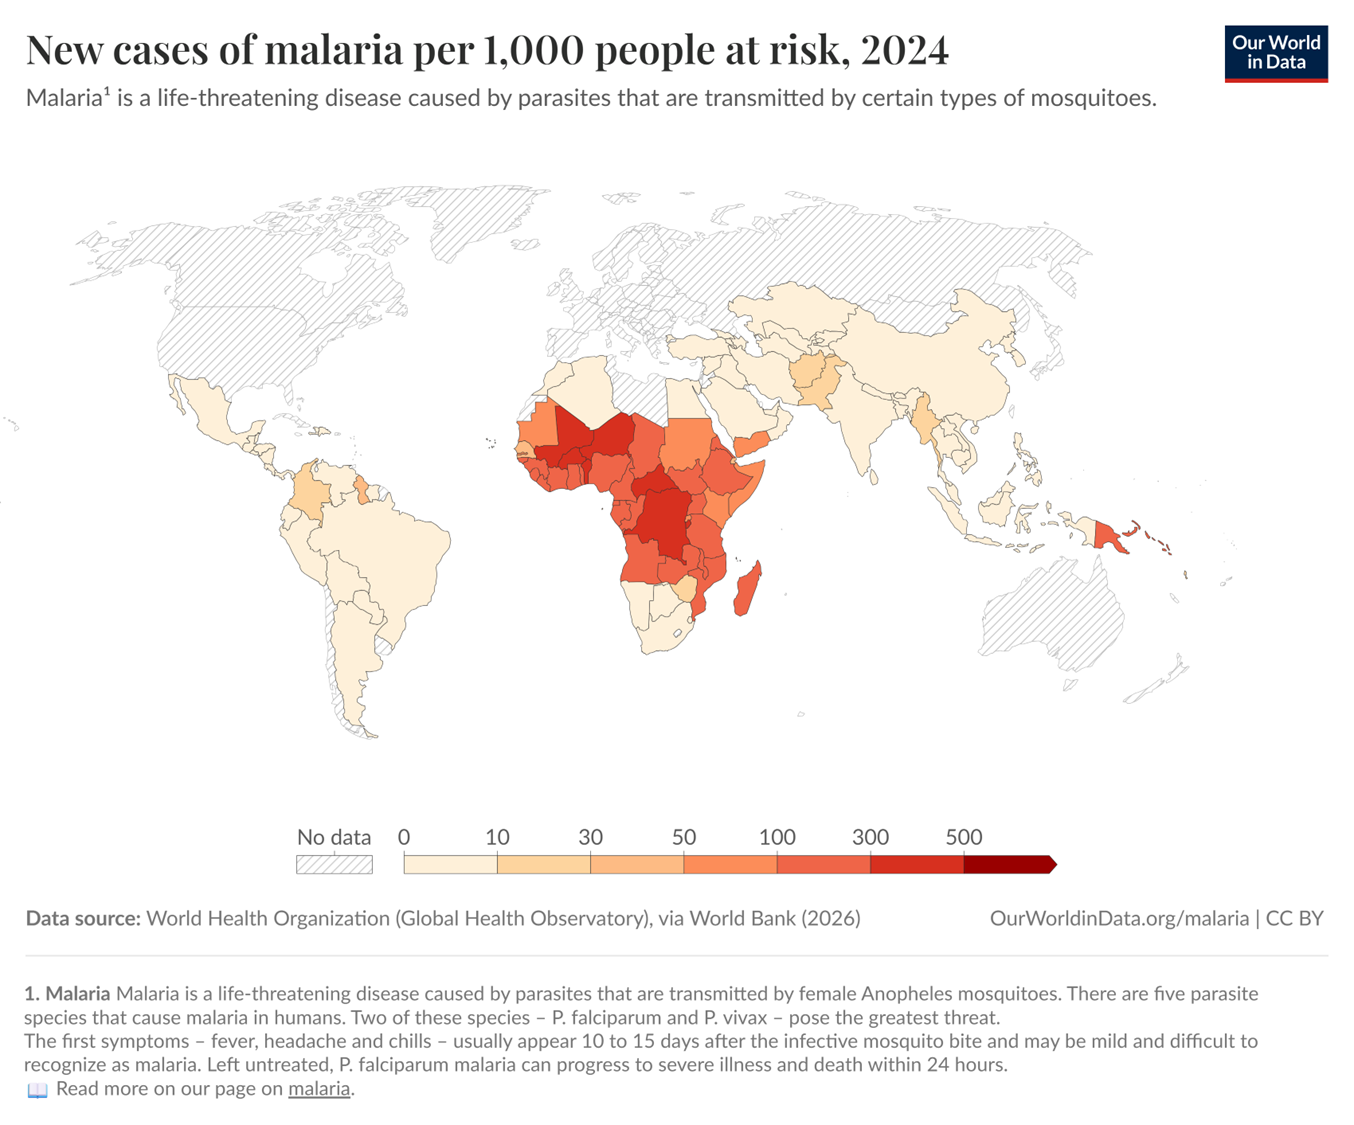

**The objectives:** The goal is to build an efficient computer vision model capable of automatically classifying red blood cell images as either parasitized (infected with Plasmodium) or uninfected, providing a faster, more consistent and scalable alternative to manual microscopic diagnosis.<br>

**The key questions:** Three key questions drive this project:
- Can a deep learning model learn to reliably distinguish the subtle visual differences between uninfected and parasitized red blood cells?
- What architecture and training strategy achieves the best balance between overall accuracy and minimisation of false negatives, the most clinically dangerous error?
- Is the model robust enough to generalise to new unseen data beyond the test dataset?<br>

**The problem formulation:** This is a supervised binary image classification problem. Given a 64x64 RGB image of a red blood cell, the model must predict one of two classes - uninfected (label 0) or parasitized (label 1). The primary success metric is test accuracy with particular attention to recall on the parasitized class to minimize missed diagnosis.

## <b>Data Description </b>

There are a total of 24,958 train and 2,600 test images (colored) that we have taken from microscopic images. These images are of the following categories:<br>


**Parasitized:** The parasitized cells contain the Plasmodium parasite which causes malaria<br>
**Uninfected:** The uninfected cells are free of the Plasmodium parasites<br>


## <b>Key Findings </b>

**Data Exploration:**

- The dataset is well balanced with 12,582 parasitized and 12,376 uninfected cells in the training set, and exactly 1,300 of each in the test set, eliminating class imbalance as a concern

- The key discriminating feature between classes is a small, localised purple parasitic structure visible inside infected cells, which varies significantly in shape, size and position across images.

- ***(Annex)** HSV colour space enhances the visibility of the parasitic structure visually but proved ineffective as a direct model input with the worst performance of all models*

**Model Performance:**

| Model | Test Accuracy | False Negatives | Recall (parasitized) |
|:---|:---:|:---:|:---:|
| Base Model | 62.69% | 850 | 0.35 |
| Model 1 | 98.65% | 25 | 0.98 |
| Model 2 (BatchNorm) | 96.77% | 81 | 0.94 |
| Model 3 (Augmentation) | **98.81%** | **7** | **0.99** |
| Model 4 (VGG16) | 96.58% | 58 | 0.96 |

**Model Training:**

- A single Conv2D layer per block with constant filters (Base Model) is insufficient for this task: the model completely failed to learn discriminating features.

- Doubling Conv2D layers per block with progressive filters (16 - 32 - 64) was the single most impactful architectural improvement, driving accuracy from 62.69% to 98.65%.

- BatchNormalization (Model 2) introduced training instability: validation accuracy collapsed to 0% in epoch 1 and the model never recovered to match Model 1's performance.

- Data augmentation (Model 3) was the most effective improvement for the medically critical metric: reducing false negatives from 25 to 7 by making the model more robust to variations in cell orientation and zoom.

- VGG16 transfer learning underperformed all well-performing custom models despite having 9x more parameters, confirming that ImageNet features do not transfer optimally to microscopy cell images at 64×64 resolution.

**Final Model Recommendation**

Model 3 with data augmentation is the recommended solution: 98.81% accuracy, recall of 0.99 on parasitized cells and only 7 missed infections out of 1,300. At 4.28 MB, it is lightweight enough for deployment on basic field equipment in resource-limited endemic regions where malaria burden is highest.

**Classification Report - Model 3 - Data Augmentation**

| | Precision | Recall | F1-Score | Support |
|:---|:---:|:---:|:---:|:---:|
| **Uninfected (0)** | 0.99 | 0.98 | 0.99 | 1300 |
| **Parasitized (1)** | 0.98 | 0.99 | 0.99 | 1300 |
| **Accuracy** | | | 0.99 | 2600 |
| **Macro avg** | 0.99 | 0.99 | 0.99 | 2600 |
| **Weighted avg** | 0.99 | 0.99 | 0.99 | 2600 |

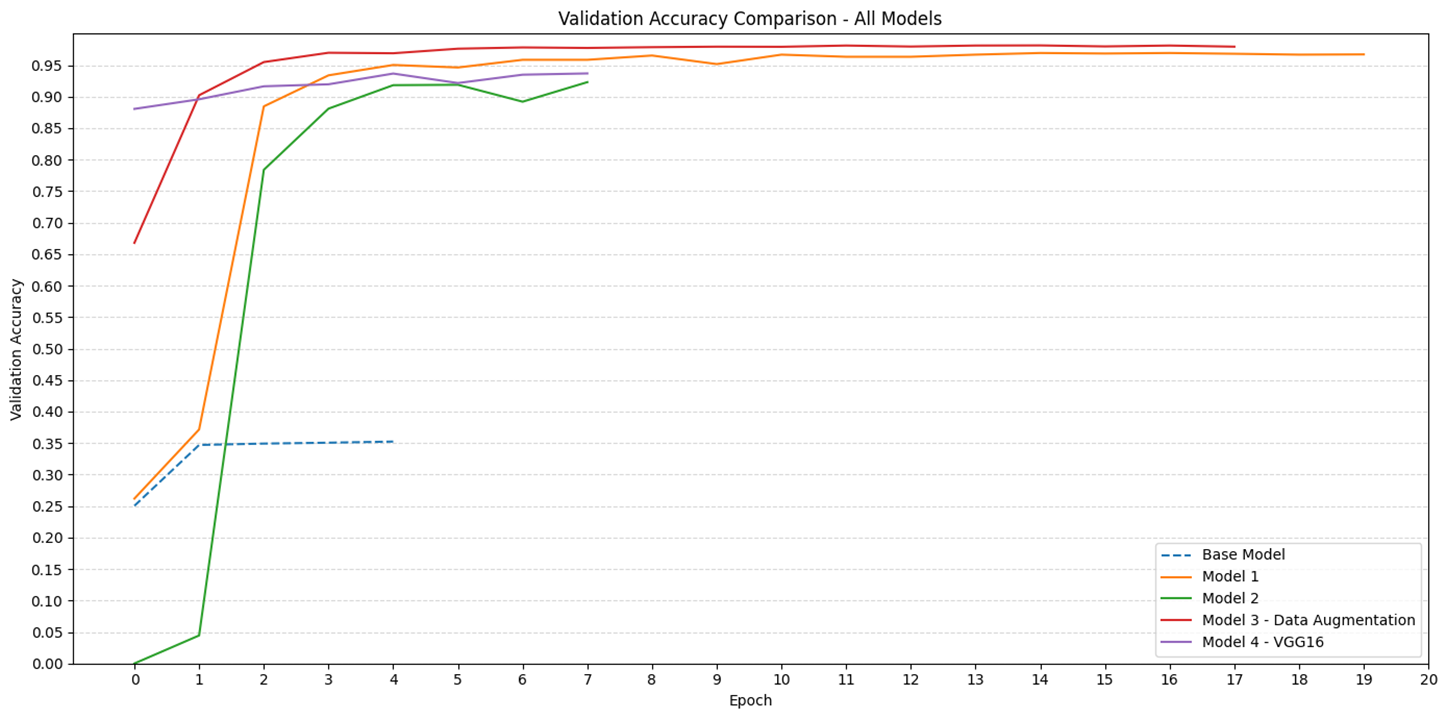

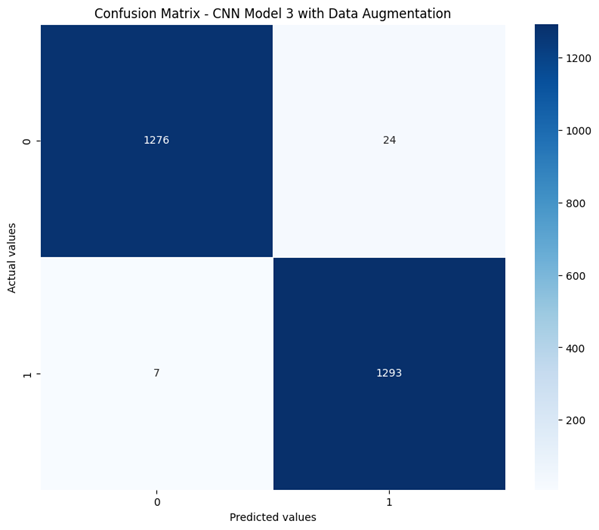

## <b>Risks and Challenges </b>

**Risks**

- Antimalarial drug resistance undermining detection: pfhrp2 gene deletions have been reported in 42 endemic countries, meaning the parasites our model was trained to detect visually may look different in regions where genetic mutations alter parasite appearance under microscopy

- Funding instability: total malaria funding in 2024 reached only 3.9 billion USD, less than half of the 9.3 billion USD required, making sustained investment in AI diagnostic tools uncertain in the regions that need them most.

- Model performance in urban settings: the invasive mosquito species Anopheles stephensi has expanded into nine African countries, potentially introducing new parasite strains in urban environments where the model has not been validated.

**Challenges**

- Integration with existing diagnostic infrastructure: rapid diagnostic tests are already widely deployed across endemic regions; convincing health programs to adopt an AI microscopy tool alongside or instead of established RDTs requires evidence of clear added value.

- Reaching the highest burden populations: five countries: the Democratic Republic of the Congo, Ethiopia, Mozambique, Nigeria and Uganda — contribute more than half of all global cases, yet these are precisely the countries with the most limited laboratory infrastructure and internet connectivity for deploying AI tools.

- Keeping pace with evolving parasites: artemisinin partial resistance has been confirmed in multiple African countries and is spreading from multiple independent origins. As parasite biology evolves, the visual features the model learned to detect may shift, requiring continuous retraining on updated microscopy data.

## <b>Recommendations for implementation: </b>

**Deployment Timeline**

**Phase 1 - Research Validation (Months 1-6)**

Test the model on independent datasets from different microscopes, laboratories and geographic regions. Confirm that the 99% recall holds beyond the current test set through comparison against expert microscopists.

**Phase 2 - Clinical Trial Preparation (Months 6-12)**

Partner with medical institutions and ethics committees to design a prospective clinical trial. Build the software around the model: user interface, audit logs, data security and human review workflow for uncertain cases.

**Phase 3 - Pilot Clinical Trial (Months 12-24)**

Run the model in parallel with standard manual diagnosis at partner clinics without replacing human judgment. Collect real-world performance data, identify failure cases, retrain if necessary and gather usability feedback.

**Phase 4 - Regulatory Submission (Months 24-36)**

Submit for FDA approval, CE marking or WHO prequalification depending on target market. This step alone can take up to 2 years and requires a robust clinical evidence dossier.

**Phase 5 - Limited Market Release (Months 36-42)**

Controlled rollout to certified laboratories with technician training, support infrastructure and continuous performance monitoring against pre-deployment benchmarks.

**Phase 6 - Full Deployment (Months 42+)**

Broad commercial or humanitarian deployment with ongoing monitoring, periodic retraining and regulatory-compliant version updates.

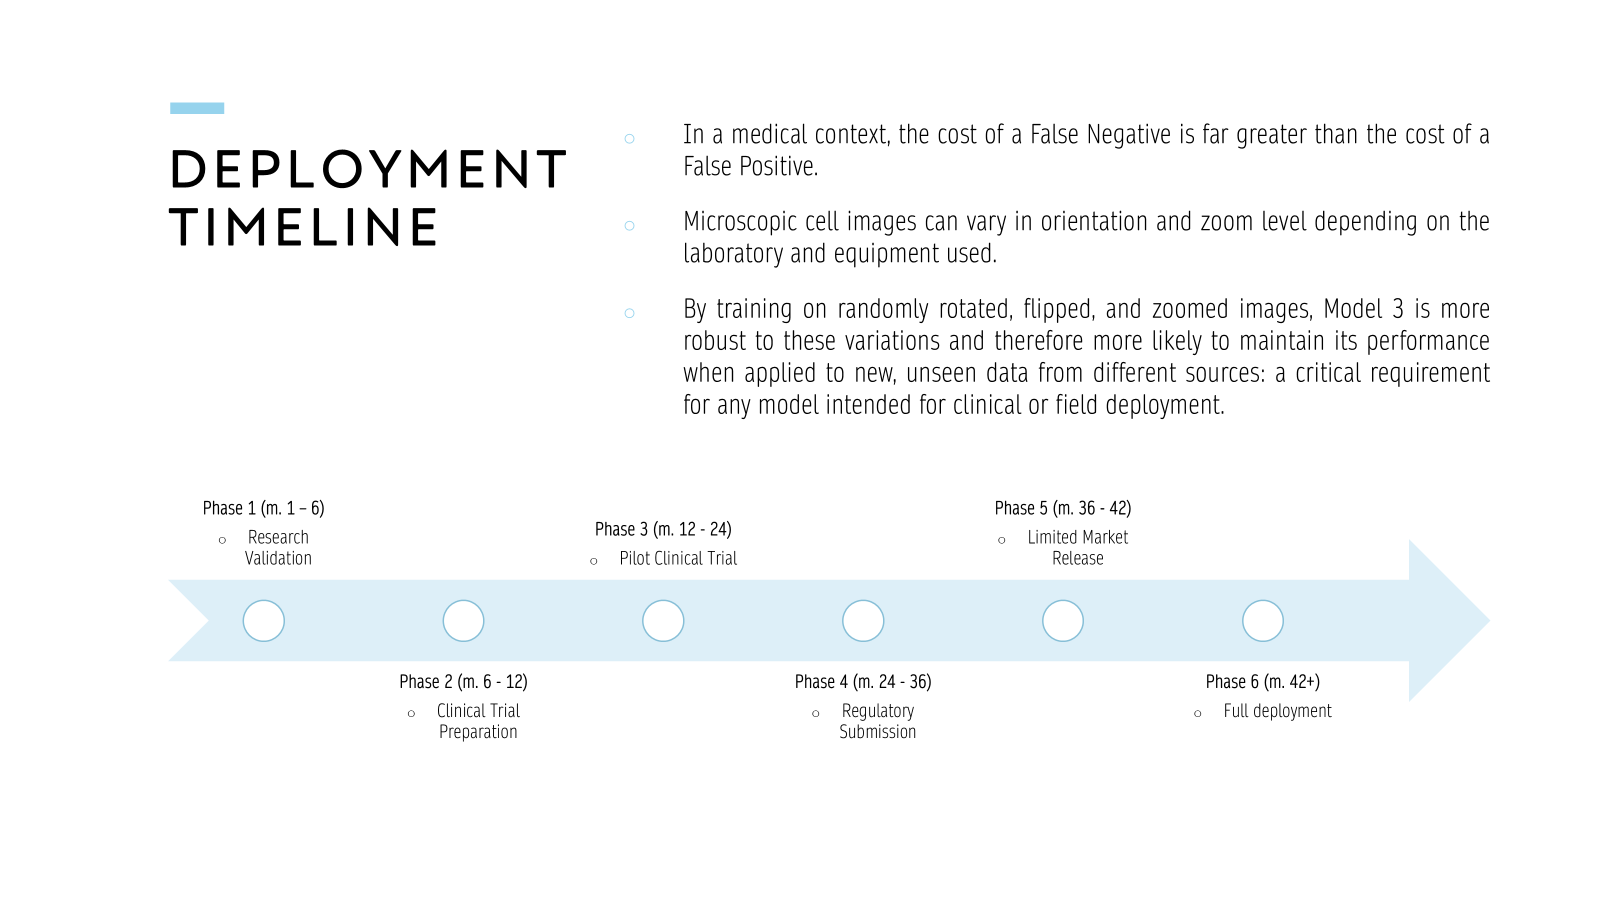

## <b>Next Steps </b>

The results achieved in this project are promising, but several steps are required before this model can be considered ready for real-world clinical use.

The most immediate priority is external validation. The model was trained and tested on a single dataset from one source. To confirm that the 99% recall holds beyond this specific dataset, the model needs to be tested on images from different microscopes, different laboratories and different geographic regions, particularly in the five highest burden countries identified by the WHO (Democratic Republic of the Congo, Ethiopia, Mozambique, Nigeria and Uganda). Variability in image quality, staining techniques and cell preparation across laboratories could significantly affect performance.

A second important next step is retraining on more diverse data. The current dataset contains only two parasite classes: parasitized and uninfected. In reality, malaria is caused by five different Plasmodium species, each with slightly different visual appearances under microscopy. Expanding the training data to include multiple species and multiple parasite life stages would make the model significantly more useful in a clinical setting.

A third area for improvement is addressing the emerging threat of antimalarial drug resistance. As highlighted in the WHO World Malaria Report 2025, pfhrp2 gene deletions have been reported in 42 endemic countries, potentially altering the visual appearance of parasites under microscopy. The model will need to be periodically retrained on updated microscopy data to remain effective as parasite biology evolves.

From a technical perspective, model robustness could be further improved by experimenting with architectures pre-trained on medical imaging datasets rather than ImageNet, applying more aggressive data augmentation to simulate different microscope qualities, and exploring ensemble approaches that combine multiple models to reduce false negatives further.

Finally, the model needs to be wrapped into a deployable application: a lightweight interface that allows a laboratory technician to photograph a blood smear, upload it and receive an immediate classification result, with uncertain cases flagged for human review. This would be the bridge between the current research prototype and a tool that could genuinely contribute to malaria diagnosis in resource-limited settings.

## <b>Source Code </b>

###<b> Mount the Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### <b>Loading libraries</b>

In [ ]:
#Importing the libraries necessary to load and resize the images
import zipfile
import os
from PIL import Image

# Importing the common and necessary libraries for data science
# Pandas for manipulating dataframes
import pandas as pd
# Numpy for manipulating arrays
import numpy as np
# Matlplotlib for data visualisation
import matplotlib.pyplot as plt
# Seaborn for statistical data visualisation
import seaborn as sns
# Random for generating random numbers
import random

# Scikit-learn for machine learning
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score, classification_report
# Library for splitting the data
from sklearn.model_selection import train_test_split

# Tensorflow for machine learning and building neural networks
import tensorflow as tf
# Tensorflow.keras API for deep learning
from tensorflow.keras import backend # backend for clearing and reseting the session
from tensorflow.keras.models import Sequential, load_model # Sequential for building linear stacks of layers
from tensorflow.keras.utils import to_categorical # to_categorical to convert arrays and matrices to categorical data
# Layers and optimizers for importing all the different layers and optimizers
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization, Activation, LeakyReLU
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint # to stop training when it stops improving and to save the best model

# ImageDataGenerator for Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# TensorFlow.keras VGG16 model for Transfer Learning
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras import Model

# OpenCV for image processing operations
import cv2

# Dectivate clipping logs from matplotlib
import logging
logging.getLogger('matplotlib.image').setLevel(logging.ERROR)

# The below code can be used to ignore the warnings that may occur due to deprecations
import warnings
warnings.filterwarnings("ignore")

### <b>Let us load the data</b>

**Note:**
- You must download the dataset from the link provided on Olympus and upload the same to your Google Drive. Then unzip the folder.

In [ ]:
# Storing the path of the .zip file on my personal Google Drive
path = '/content/drive/MyDrive/Capstone Project/cell_images.zip'

# Unpacking the dataset to the Google Colab local storage for more convenient I/O operation and handling
with zipfile.ZipFile(path, 'r') as zip_ref:
  zip_ref.extractall('/content/')


In [ ]:
# Checking the folder content and the labels
print(f'The folder "content" contains the following folders: {os.listdir('/content/')}')
print(f'The folder "cell_images" contains the following folders: {os.listdir('/content/cell_images/')}')
print(f'The folder "train" contains the following folders: {os.listdir('/content/cell_images/train/')}')
print(f'The folder "parasitized" contains images like those first three: {os.listdir('/content/cell_images/train/parasitized/')[:3]}')

The folder "content" contains the following folders: ['.config', 'cell_images', 'best_model1.keras', 'best_model2.keras', 'best_model_vgg.keras', 'best_model.keras', 'best_model3.keras', 'best_model_hsv.keras', 'best_model_base.keras', 'best_model_gen.keras', 'drive', 'sample_data']
The folder "cell_images" contains the following folders: ['train', 'test']
The folder "train" contains the following folders: ['uninfected', 'parasitized']
The folder "parasitized" contains images like those first three: ['C189P150ThinF_IMG_20151203_141901_cell_82.png', 'C101P62ThinF_IMG_20150923_170344_cell_82.png', 'C51AP12thinF_IMG_20150724_154243_cell_122.png']


The extracted folder has different folders for train and test data will contain the different sizes of images for parasitized and uninfected cells within the respective folder name.

The size of all images must be the same and should be converted to 4D arrays so that they can be used as an input for the convolutional neural network. Also, we need to create the labels for both types of images to be able to train and test the model.

Let's do the same for the training data first and then we will use the same code for the test data as well.

Opening the file: C189P150ThinF_IMG_20151203_141901_cell_82.png
The size of the sample image is (118, 142)
The size of a sample image after resizing is (64, 64)


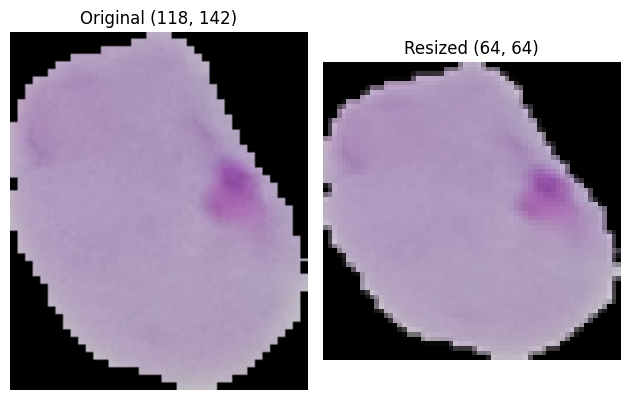

In [ ]:
# Inspecting one image before proceeding with the entire folder
# This helps verify the image loading, resizing and display
# Trying with the train dataset and parasitized images
folder_path = '/content/cell_images/train/parasitized/'
file = os.listdir(folder_path)[0]
print(f'Opening the file: {file}')

# Opening a sample image and verifying the size
img = Image.open(os.path.join(folder_path, file))
print(f'The size of the sample image is {img.size}')

# Resizing the image to the target size 64x64
res = img.resize((64, 64))
print(f'The size of a sample image after resizing is {res.size}')

# Displaying the sample resized image
plt.subplot(1, 2, 1)
plt.title(f'Original {img.size}')
plt.imshow(img)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title(f'Resized {res.size}')
plt.imshow(res)
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Storing the train dataset path into a separate variable
train_path = ('/content/cell_images/train/')

# Creating lists to store the images and labels after extraction
train_images = []
train_labels = []

# Looping through the entire dataset to open the images, extract and store them with the labels in the corresponding lists
for category, label in [('uninfected', 0), ('parasitized', 1)]:
    category_folder_path = os.path.join(train_path, category)
    for file in os.listdir(category_folder_path):
      try:
        img_path = os.path.join(category_folder_path, file)
        img = Image.open(img_path)
        img = img.resize((64, 64))
        img = np.array(img)
        train_images.append(img)
        train_labels.append(label)
      except Exception as e:
        print(f'Skipping file {file}: {e}')
        continue

# Converting lists to Numpy arrays
train_images = np.array(train_images)
train_labels = np.array(train_labels)

C70P31_ThinF_IMG_20150813_130849_cell_69.png
The size of the sample image is (61, 79)
The size of a sample image after resizing is (64, 64)


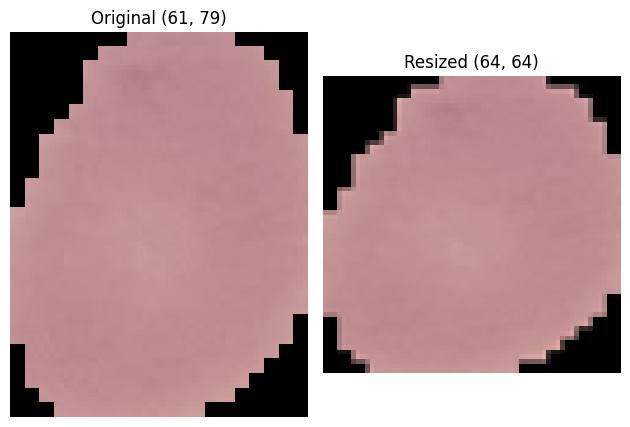

In [ ]:
# Inspecting one image before proceeding with the entire folder
# This helps verify the image loading, resizing and display
# Trying with the test dataset and uninfected images
folder_path = '/content/cell_images/test/uninfected/'
file = os.listdir(folder_path)[0]
print(file)

# Opening a sample image and verifying the size
img = Image.open(os.path.join(folder_path, file))
print(f'The size of the sample image is {img.size}')

# Resizing the image to the target size 64x64
res = img.resize((64, 64))
print(f'The size of a sample image after resizing is {res.size}')

# Displaying the sample resized image
plt.subplot(1, 2, 1)
plt.title(f'Original {img.size}')
plt.imshow(img)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title(f'Resized {res.size}')
plt.imshow(res)
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Storing the test dataset path into a separate variable
test_path = ('/content/cell_images/test/')

# Creating lists to store the images and labels after extraction
test_images = []
test_labels = []

# Looping through the entire dataset to open the images, extract and store them with the labels in the corresponding lists
for category, label in [('uninfected', 0), ('parasitized', 1)]:
    category_folder_path = os.path.join(test_path, category)
    for file in os.listdir(category_folder_path):
      try:
        img_path = os.path.join(category_folder_path, file)
        img = Image.open(img_path)
        img = img.resize((64, 64))
        img = np.array(img)
        test_images.append(img)
        test_labels.append(label)
      except Exception as e:
        print(f'Skipping file {file}: {e}')
        continue

# Converting lists to arrays
test_images = np.array(test_images)
test_labels = np.array(test_labels)

###<b> Check the shape of train and test images

In [ ]:
# Checking the shapes of the train and test datasets after extraction and resizing
print(f'The shape of the train array of images is: {train_images.shape}')
print(f'The shape of the test array of images is: {test_images.shape}')

The shape of the train array of images is: (24958, 64, 64, 3)
The shape of the test array of images is: (2600, 64, 64, 3)


###<b> Check the shape of train and test labels

In [ ]:
# Checking the shapes of the train and test arrays of labels after extraction
print(f'The shape of the array of train labels is: {train_labels.shape}')
print(f'The shape of the array of test labels is: {test_labels.shape}')

The shape of the array of train labels is: (24958,)
The shape of the array of test labels is: (2600,)


#### **Observations and insights:**

After unzipping the dataset and storing it in the Google Colab local storage, we extracted separately the train and test datasets.

On each of the dataset, we applied image processing methods to reshape every image to be 64x64 and stored them in an array and then extracted and stored the corresponding labels into a separate array.
The result is that, we have now four separate NumPy arrays:
1. A train images array of dimension (24958, 64, 64, 3)
2. A test images array of dimension (2600, 64, 64, 3)
3. A train labels array of dimension (24958, )
4. A test labels array of dimension (2600, )

- The first observation we can make is that the train images array has 24958 images of dimension 64x64 and 3 channels which corresponds to the colour space RGB.
Similarily, the test images array has 2600 images of dimension 64x64 and 3 channels which corresponds as well to the RGB space.
- The second observation is the length of the labels arrays that is corresponding to their respective images arrays. 24958 labels for the train set and 2600 for the test set.
- The third observation is that when exploring the data, we have displayed a sample image before and after resizing. We notice a slight loss of information between both. This is due to the fact that the .resize() method used from the PIL library is looking at the corresponding region from the original image for each pixel in the new 64x64 image and averaging the pixel values in that region. The result is a new pixel value. The important features that distinguish parasitized from uninfected cells are still preserved well enough for a Convolutional Neural Network (CNN) to learn from.

### <b>Check the minimum and maximum range of pixel values for train and test images

In [ ]:
# Checking the minimum and maximum values for each dataset (train and test)
print('Train dataset max and min values:')
print(f'The maximum value in the train dataset is: {train_images.max()}')
print(f'The minimum value in the train dataset is: {train_images.min()}')
print('\nTest dataset max and min values:')
print(f'The maximum value in the test dataset is: {test_images.max()}')
print(f'The minimum value in the test dataset is: {test_images.min()}')

Train dataset max and min values:
The maximum value in the train dataset is: 255
The minimum value in the train dataset is: 0

Test dataset max and min values:
The maximum value in the test dataset is: 255
The minimum value in the test dataset is: 0


#### **Observations and insights:**

The RGB space in which the images are encoded means that each image has 3 channels corresponding to the colours Red, Green and Blue. Each colour is encoded by a value that ranges from 0 to 255.

While not necessarily each image will contain all the possible values, we see that the train and test dataset images do, as the minimal value in both cases is 0 and the maximum value is 255.

This is an important information for the normalisation step that happens right after as we know by default that the maximum value for the RGB space is 255, which is not always the case of every dataset, and we also have a confirmation thanks to the above lines of code.

###<b> Count the number of values in both uninfected and parasitized

In [ ]:
# Checking the count of each category of cells in the images of the train and test dataset
print('Train dataset:')
print(f'Count for uninfected (index 0) cells in train dataset :{np.sum(train_labels == 0)}')
print(f'Count for parasitized (index 1) cells in train dataset :{np.sum(train_labels == 1)}')
print('\nTest dataset:')
print(f'Count for uninfected (index 0) cells in test dataset :{np.sum(test_labels == 0)}')
print(f'Count for parasitized (index 1) cells in test dataset :{np.sum(test_labels == 1)}')

Train dataset:
Count for uninfected (index 0) cells in train dataset :12376
Count for parasitized (index 1) cells in train dataset :12582

Test dataset:
Count for uninfected (index 0) cells in test dataset :1300
Count for parasitized (index 1) cells in test dataset :1300


###<b>Normalize the images

In [ ]:
# Normalising the dataset by dividing each value by 255
train_images_norm = (train_images/255).astype('float32')
test_images_norm = (test_images/255).astype('float32')

# Checking the data type of the array
print(f'The destination data type of the train dataset images is: {train_images_norm.dtype}')
print(f'The destination data type of the test dataset images is: {test_images_norm.dtype}')

The destination data type of the train dataset images is: float32
The destination data type of the test dataset images is: float32


In [ ]:
# Verifying that normalisation is successfull, values should be between 0 and 1
print(f'The maximum value in the train dataset is: {train_images_norm.max()}')
print(f'The minimum value in the train dataset is: {train_images_norm.min()}')
print(f'The maximum value in the test dataset is: {test_images_norm.max()}')
print(f'The minimum value in the test datset is: {test_images_norm.min()}')

The maximum value in the train dataset is: 1.0
The minimum value in the train dataset is: 0.0
The maximum value in the test dataset is: 1.0
The minimum value in the test datset is: 0.0


#### **Observations and insights:**

The dataset contains images with values that range between 0 and 255 which is expected for images in the RGB colour space.

After normalisation the values are now between 0 and 1. This is important later during model training as it makes the gradient descent convergence faster and more stable (with pixel values between 0 and 255 the inputs to the neural network are quite large, this can cause the gradients to be quite large as well).

###<b> Plot to check if the data is balanced

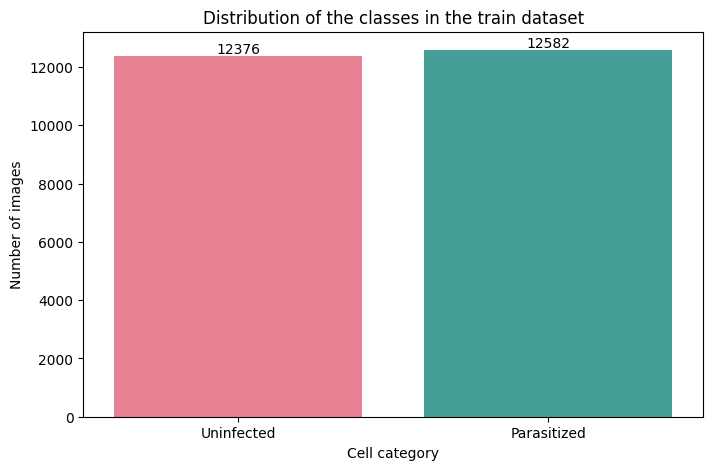

In [ ]:
# Creating a dataframe to use seaborn.countplot and to map labels to categories
train_df = pd.DataFrame({'label': train_labels})
train_df['category'] = train_df['label'].map({0: 'Uninfected', 1: 'Parasitized'})

# Plotting the class distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=train_df, x='category', palette='husl')

# Adding counts on top of the bars
for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribution of the classes in the train dataset')
plt.xlabel('Cell category')
plt.ylabel('Number of images')
plt.show()

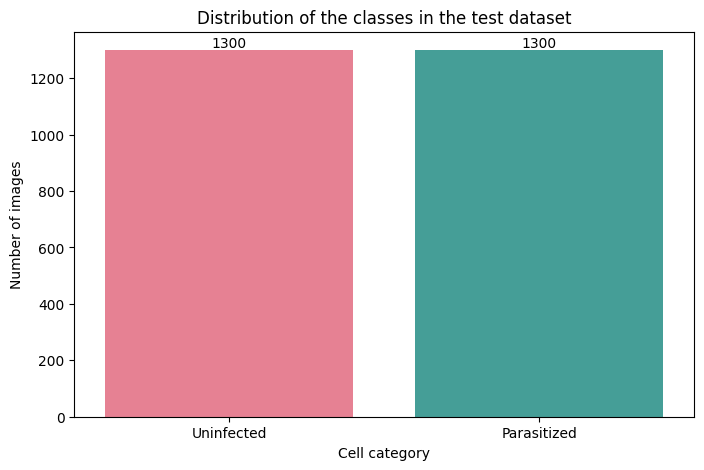

In [ ]:
# Creating a dataframe to use seaborn.countplot and to map labels to categories
test_df = pd.DataFrame({'label': test_labels})
test_df['category'] = test_df['label'].map({0: 'Uninfected', 1: 'Parasitized'})

# Plotting the class distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=test_df, x='category', palette='husl')

# Adding counts on top of the bars
for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribution of the classes in the test dataset')
plt.xlabel('Cell category')
plt.ylabel('Number of images')
plt.show()

#### **Observations and insights:**

The distribution in the train dataset is as follows:
- 12582 images of parasitized cells
- 12376 images of uninfected cells

As for the test dataset:
- 1300 images of parasitized cells
- 1300 images of uninfected cells

Both datasets are balanced with the test dataset being equally balanced. This is important as we move on with training our model to have a balanced dataset to not give a higher weight to one or the other category in the train and the test dataset as well.

For example, if we would have 90% of uninfected cells in our dataset, the model could achieve quickly a very high accuracy while being weak in identifying parasitized cells and potentially outputting a lot of false negative results (parasitized cell identified as healthy) and this is dangerous in a medical diagnostic context.

### <b>Data Exploration</b>
Let's visualize the images from the train data

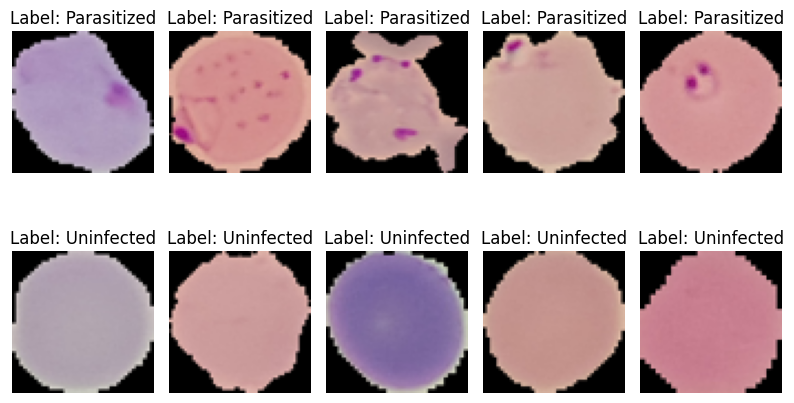

In [ ]:
# Visualising 5 images from each class
plt.figure(figsize=(8, 5))

# Variable to map indices to labels
label_map = {0: 'Uninfected', 1: 'Parasitized'}

# Extracting indices for both classes
parasitized_idx = np.where(train_labels == 1)[0][:5]
uninfected_idx = np.where(train_labels == 0)[0][:5]
selected_indices = np.concatenate([parasitized_idx, uninfected_idx])

# Displaying the images in a 2x5 grid with titles
for i, idx in enumerate(selected_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images[idx])
    plt.title(f'Label: {label_map[train_labels[idx]]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

#### **Observations and insights:**

We see 5 images of parasitized cells and 5 images of uninfected cells from the train dataset.
- All cells have different tints ranging from grey to pink and this parameter is not differentiating cells from both categories.
- The same can be said about the shape, while most cells have a round shape some have an irregular shape and again this parameter doesn't help differentiating cells from both categories.
- When taking a closer look, we can notice that the parasitized cells have a tiny purple structure inside of them which the uninfected clearly doesn't have, the tint of this parasitic structure is strong and clearly discriminatory. This is the main difference between both cell categories.
- This analysis suggests that the convolutional neural network will have to detect small localised features within the cell, which is well suited to CNNs with small filters.

###<b> Visualize the images with subplot(6, 6) and figsize = (12, 12)

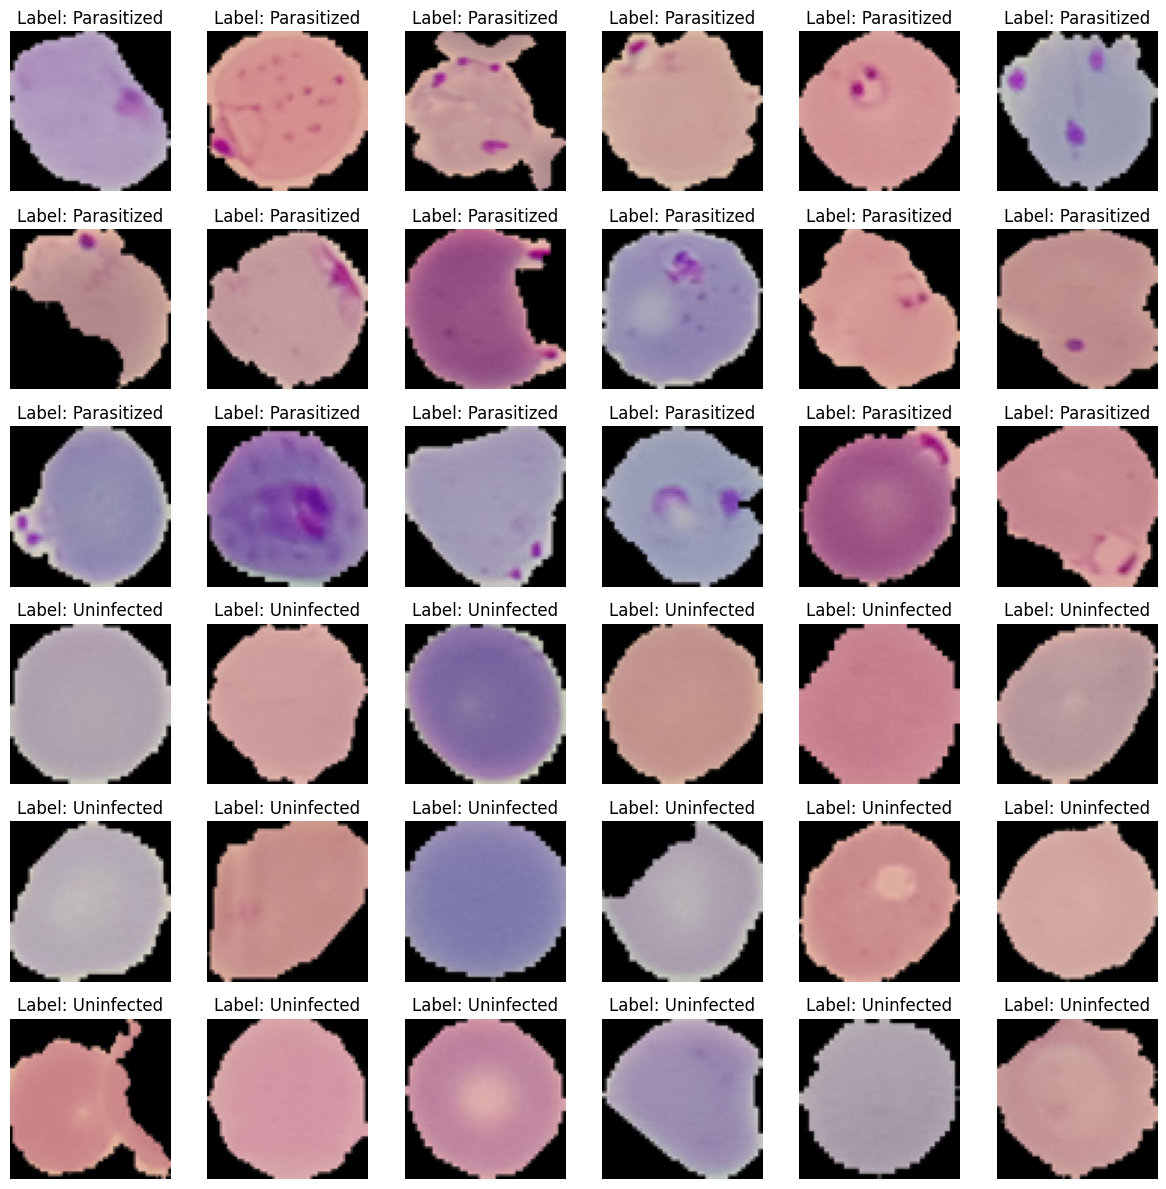

In [ ]:
# Visualising 18 images from each class (36 in total)
plt.figure(figsize=(12, 12))

# Variable to map indices to labels
label_map = {0: 'Uninfected', 1: 'Parasitized'}

# Extracting indices for both classes
parasitized_idx = np.where(train_labels == 1)[0][:18]
uninfected_idx = np.where(train_labels == 0)[0][:18]
selected_indices = np.concatenate([parasitized_idx, uninfected_idx])

# Displaying the images in a 6x6 grid with titles
for i, idx in enumerate(selected_indices):
    plt.subplot(6, 6, i + 1)
    plt.imshow(train_images[idx])
    plt.title(f'Label: {label_map[train_labels[idx]]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

#### **Observations and insights:**

The display of 36 cells helps notice a few things that previously we couldn't notice.
- The uninfected cells show an important colour variation from grey to different tints of orange/pink.
- The parasitized cells show also many different tints, but more importantly, the parasitic structure is not just a smaller cell within the cell but can take the shape of an entire area or a circular shape or many different small spread structures.
- This analysis is important as there is a lot of colour variation and different cell shapes that are not discriminatory features for both categories and the parasitic structure which also has a lot of variation in shapes is discriminatory. The training of the model will probably need sufficient depth to identify all the structures and discriminate correctly by focusing on the parasitic structure.

###<b> Plotting the mean images for parasitized and uninfected

<b> Mean image for parasitized

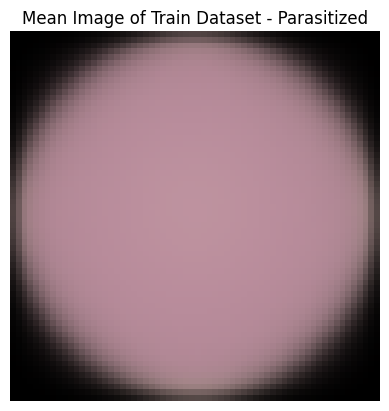

In [ ]:
# Calculate the mean image for parasitized cells
parasitized_mean = np.mean(train_images_norm[train_labels == 1], axis=0)

# Displaying the mean image
plt.imshow(parasitized_mean)
plt.title('Mean Image of Train Dataset - Parasitized')
plt.axis('off')
plt.show()

<b> Mean image for uninfected

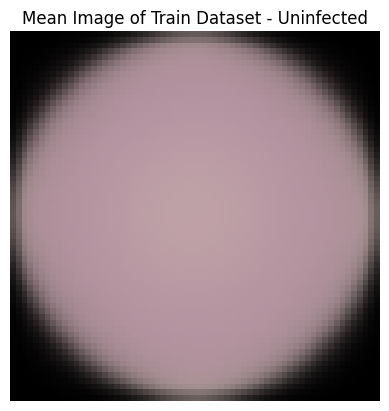

In [ ]:
# Calculate the mean image for uninfected cells
uninfected_mean = np.mean(train_images_norm[train_labels == 0], axis=0)

# Displaying the mean image
plt.imshow(uninfected_mean)
plt.title('Mean Image of Train Dataset - Uninfected')
plt.axis('off')
plt.show()

#### **Observations and insights:**

Both Mean images are very similar, yet we notice a slightly darker tint in the parasitized mean image compared to the uninfected.
- The parasitic structures are absent from the parasitized mean image which is expected as this is an average calculation of the values of the image.
- The purple parasitic structure can be found in many different areas of the cell therefore averaging is similar to adding a purple filter to the mean image which explains the slightly darker tint of the parasitized mean image.

### <b>Converting RGB to HSV of Images using OpenCV

###<b> Converting the train data

In [ ]:
# The HSV (Hue, Saturation, Value) space is often more efficient when the task is to isolate structures based on colour
train_images_hsv = [cv2.cvtColor(img, cv2.COLOR_RGB2HSV) for img in train_images_norm]

# Convertin to a numpy array
train_images_hsv = np.array(train_images_hsv)

# Verifying the shape of the array
print(f'HSV train dataset dimensions are : {train_images_hsv.shape}')

HSV train dataset dimensions are : (24958, 64, 64, 3)


In [ ]:
# Verifying the values of each channel for the train dataset after conversion to HSV
print('Maximum values: \n')
print(f'The maximum hue in the train dataset is: {train_images_hsv[:,:,:,0].max()}')
print(f'The maximum saturation in the train dataset is: {train_images_hsv[:,:,:,1].max()}')
print(f'The maximum value in the train dataset is: {train_images_hsv[:,:,:,2].max()} \n')
print('Minimum values: \n')
print(f'The minimum hue in the train dataset is: {train_images_hsv[:,:,:,0].min()}')
print(f'The minimum saturation in the train dataset is: {train_images_hsv[:,:,:,1].min()}')
print(f'The minimum value in the train dataset is: {train_images_hsv[:,:,:,2].min()}')

Maximum values: 

The maximum hue in the train dataset is: 359.3616943359375
The maximum saturation in the train dataset is: 0.9999998211860657
The maximum value in the train dataset is: 1.0 

Minimum values: 

The minimum hue in the train dataset is: 0.0
The minimum saturation in the train dataset is: 0.0
The minimum value in the train dataset is: 0.0


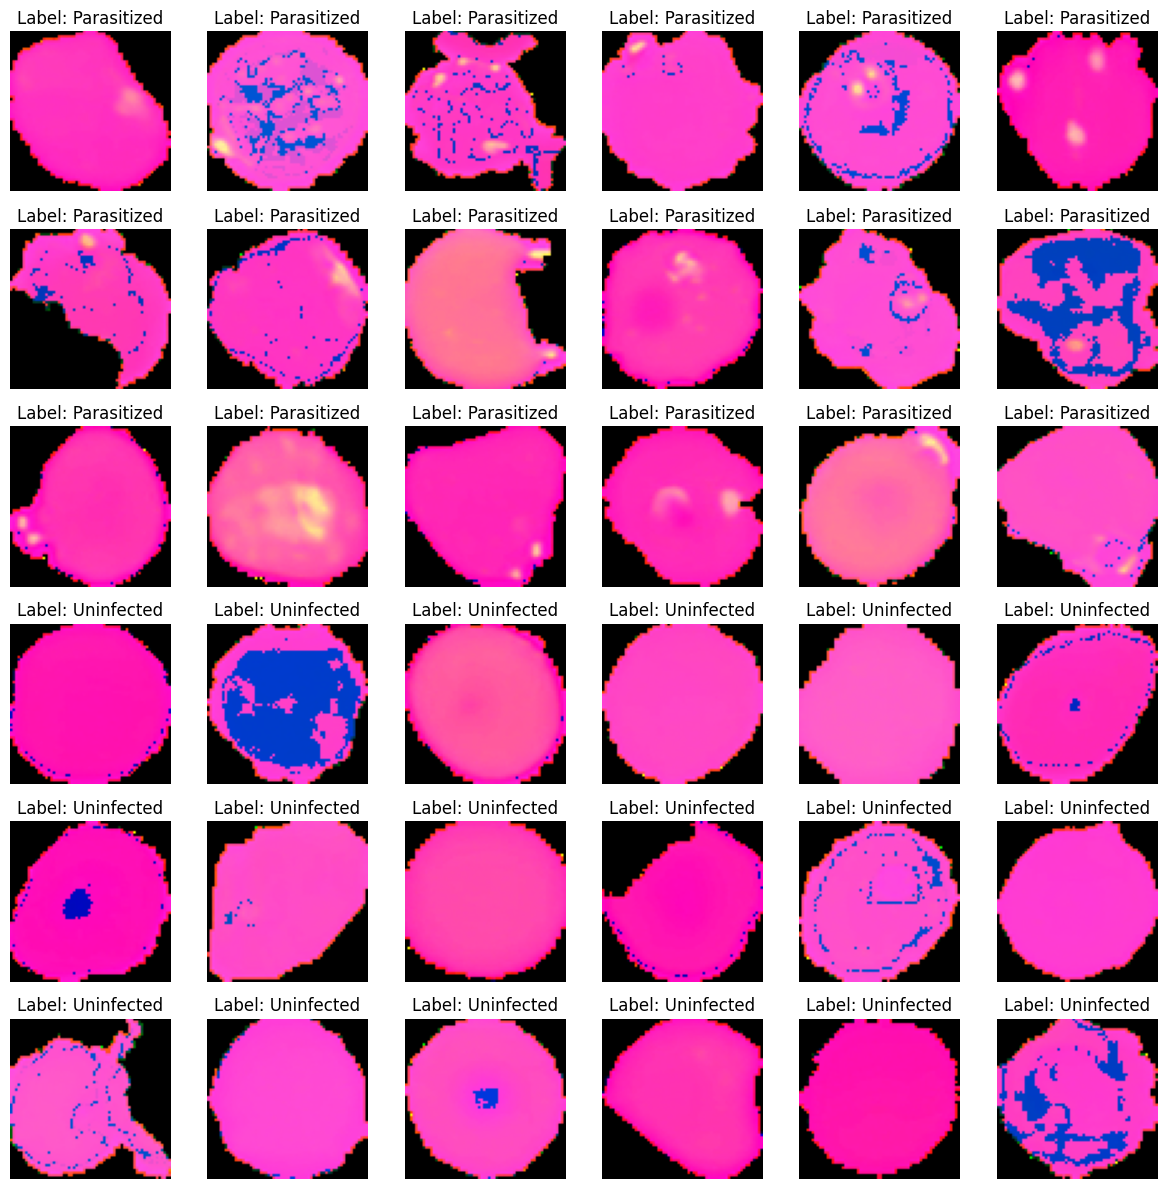

In [ ]:
# Visualising 18 images from each class (36 in total)
plt.figure(figsize=(12, 12))

# Variable to map indices to labels
label_map = {0: 'Uninfected', 1: 'Parasitized'}

# Extracting indices for both classes
parasitized_idx = np.where(train_labels == 1)[0][:18]
uninfected_idx = np.where(train_labels == 0)[0][:18]
selected_indices = np.concatenate([parasitized_idx, uninfected_idx])

# Displaying the images in a 6x6 grid with titles
for i, idx in enumerate(selected_indices):
    plt.subplot(6, 6, i + 1)
    plt.imshow(train_images_hsv[idx])
    plt.title(f'Label: {label_map[train_labels[idx]]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

###<b> Converting the test data

In [ ]:
# The HSV (Hue, Saturation, Value) space is often more efficient when the task is to isolate structures based on colour
test_images_hsv = [cv2.cvtColor(img, cv2.COLOR_RGB2HSV) for img in test_images_norm]

# Convertin to a numpy array
test_images_hsv = np.array(test_images_hsv)

# Verifying the shape of the array
print(f'HSV test dataset dimensions are : {test_images_hsv.shape}')

HSV test dataset dimensions are : (2600, 64, 64, 3)


In [ ]:
# Verifying the values of each channel for the test dataset after conversion to HSV
print('Maximum values: \n')
print(f'The maximum hue in the test dataset is: {test_images_hsv[:,:,:,0].max()}')
print(f'The maximum saturation in the test dataset is: {test_images_hsv[:,:,:,1].max()}')
print(f'The maximum value in the test dataset is: {test_images_hsv[:,:,:,2].max()} \n')
print('Minimum values: \n')
print(f'The minimum hue in the test dataset is: {test_images_hsv[:,:,:,0].min()}')
print(f'The minimum saturation in the test dataset is: {test_images_hsv[:,:,:,1].min()}')
print(f'The minimum value in the test dataset is: {test_images_hsv[:,:,:,2].min()}')

Maximum values: 

The maximum hue in the test dataset is: 359.3258361816406
The maximum saturation in the test dataset is: 0.9999998211860657
The maximum value in the test dataset is: 1.0 

Minimum values: 

The minimum hue in the test dataset is: 0.0
The minimum saturation in the test dataset is: 0.0
The minimum value in the test dataset is: 0.0


#### **Observations and insights:**

After converting the train and test datasets to the HSV colour space, we notice important features.
- All cells have become mostly fluorescent pink with nuances of pink that are less visible than in the RGB original images.
- While the colours in HSV differ significantly to their RGB counterparts, some features are much more visible: this is the case of the blue patterns. It seems those appear in cells that originally have a pale orange tint. Blue patterns are present in uninfected and parasitized cells and are not a discriminatory feature.
- Much more interesting are the yellow structures present in parasitized cells only. They point out to the parasitic structure and are much more differentiated to the rest of the cell in the HSV colour space.
- The enhanced visibility of the parasitic structures in HSV could be used as a complement to the RGB images for the model training, potentially improving the model ability to detect those structures.

*This hypothesis has been tested in the annex section where a training model on HSV images has been developed - see annex for details.*

###<b> Processing Images using Gaussian Blurring

###<b> Gaussian Blurring on train data

In [ ]:
# Adding a Gaussian Blurring to the train images
train_images_gb = [cv2.GaussianBlur(img, (3, 3), 0) for img in train_images_norm]

# Converting to a numpy array
train_images_gb = np.array(train_images_gb)

# Verifying the shape of the array
print(f'Gaussian Blur train dataset dimensions are : {train_images_gb.shape}')

Gaussian Blur train dataset dimensions are : (24958, 64, 64, 3)


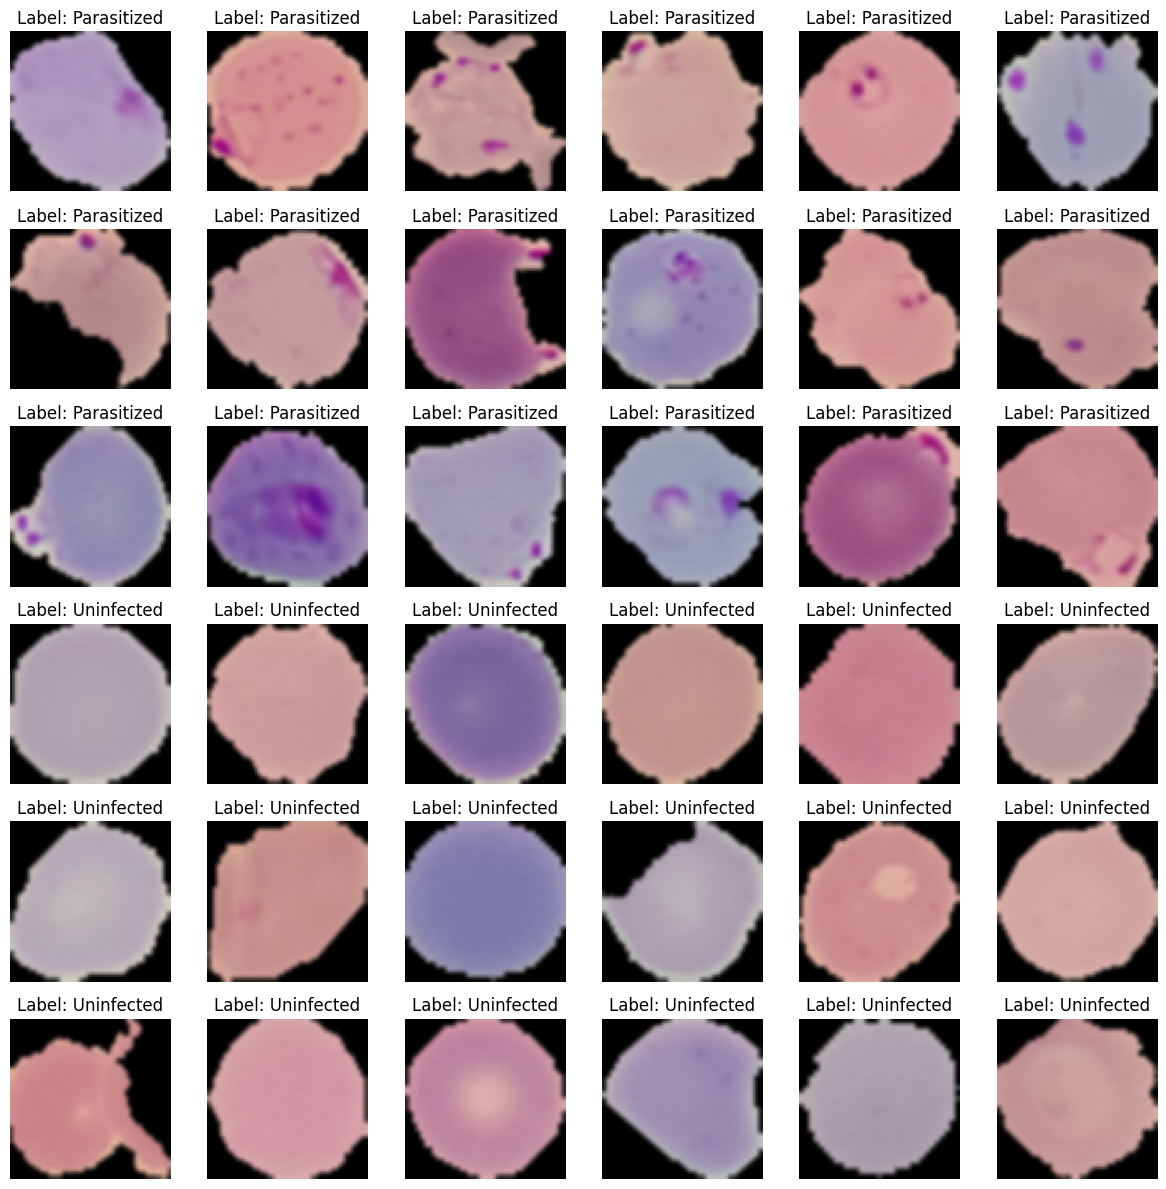

In [ ]:
# Visualising 18 images from each class (36 in total)
plt.figure(figsize=(12, 12))

# Variable to map indices to labels
label_map = {0: 'Uninfected', 1: 'Parasitized'}

# Extracting indices for both classes
parasitized_idx = np.where(train_labels == 1)[0][:18]
uninfected_idx = np.where(train_labels == 0)[0][:18]
selected_indices = np.concatenate([parasitized_idx, uninfected_idx])

# Displaying the images in a 6x6 grid with titles
for i, idx in enumerate(selected_indices):
    plt.subplot(6, 6, i + 1)
    plt.imshow(train_images_gb[idx])
    plt.title(f'Label: {label_map[train_labels[idx]]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

###<b> Gaussian Blurring on test data

In [ ]:
# Adding a Gaussian Blurring to the test images
test_images_gb = [cv2.GaussianBlur(img, (3, 3), 0) for img in test_images_norm]

# Converting to a numpy array
test_images_gb = np.array(test_images_gb)

# Verifying the shape of the array
print(f'Gaussian Blur test dataset dimensions are : {test_images_gb.shape}')

Gaussian Blur test dataset dimensions are : (2600, 64, 64, 3)


####**Observations and insights:**

**Think About It:** Would blurring help us for this problem statement in any way? What else can we try?

- The images after applying Gaussian Blurring are relatively recognisable when compared to their RGB counterparts. The smoothing is subtle and since the size of images is 64x64 which is not a huge size, the kernel has been set to 3x3.
- Gaussian Blurring applies a gaussian weighted averaging of neighbouring pixels that smooths the features in the image making them less sharp. This has consequences for the detection of the parasitized cells. If Gaussian Blurring smooths the small sharp structures (like the parasitic structure), we can expect that a model trained on images filtered with Gaussian Blurring would perform worse.

## **Model Building**

### **Base Model**




###<b> Importing the required libraries for building and training our Model

In [ ]:
# /!\ DISCLAIMER: I have moved all libraries to the second cell of this notebook

####<B>One Hot Encoding the train and test labels

In [ ]:
# Encoding the label vectors with the keras library
train_labels_encoded = to_categorical(train_labels, 2)
test_labels_encoded = to_categorical(test_labels, 2)

# Printing the shapes to verify the encoding is correct
print(f'The shape of the encoded train labels is: {train_labels_encoded.shape}')
print(f'The shape of the encoded test labels is: {test_labels_encoded.shape}')

# Printing the first 5 values to verify the encoded vectors are correct
print(f'The first 5 values of the encoded train labels are: {train_labels_encoded[:5]}')
print(f'The first 5 values of the encoded test labels are: {test_labels_encoded[:5]}')

The shape of the encoded train labels is: (24958, 2)
The shape of the encoded test labels is: (2600, 2)
The first 5 values of the encoded train labels are: [[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]
The first 5 values of the encoded test labels are: [[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


###<b> Building the model

In [ ]:
# Session clearing before model training
backend.clear_session()

# Setting a seed to ensure we have reproducible results
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Sequential means that the model is built as a linear stacks of layers

# Conv2D: applies 16 learnable filters of size 3x3 across the image
  # Each filter slides across the 64x64 image detecting local patterns such as edges, curves and textures
  # padding='same': adds zeros around borders so output keeps 64x64 dimensions
  # input_shape=(64, 64, 3): 64x64 RGB image

# MaxPooling2D: reduces spatial dimensions by taking the maximum value in each 2x2 window
  # MaxPooling reduces computational cost, introduces spatial invariance and retains only the strongest features by taking the maximum value in each 2x2 window

# Dropout layers are added with 20% of neurons turned off after each MaxPooling2D

# The Flatten layer is used after all Conv2D layers have been applied to transform spatial information into feature representations

# The output layer has a softmax activation function
  # The softmax function is defined between 0 and 1
  # This is very practical as we want probabilities as the ouput

# .summary() prints the model architecture summary showing:
# - Each layer type and name
# - Output shape at each layer
# - Number of trainable parameters per layer
# - Total parameter count

def cnn_model_base():
  cnn_model = Sequential()

  cnn_model.add(Conv2D(filters = 16, kernel_size = 3, padding = "same", activation = "relu", input_shape = (64, 64, 3)))
  cnn_model.add(MaxPooling2D((2, 2)))

  cnn_model.add(Dropout(0.2))

  cnn_model.add(Conv2D(filters = 16, kernel_size = 3, padding = "same", activation = "relu"))
  cnn_model.add(MaxPooling2D((2, 2)))

  cnn_model.add(Dropout(0.2))

  cnn_model.add(Conv2D(filters = 16, kernel_size = 3, padding = "same", activation = "relu"))
  cnn_model.add(MaxPooling2D((2, 2)))

  cnn_model.add(Dropout(0.2))

  cnn_model.add(Flatten())

  cnn_model.add(Dense(256, activation='relu'))

  cnn_model.add(Dense(2, activation='softmax'))

  return cnn_model

# Model initialisation
cnn_model_base = cnn_model_base()

cnn_model_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,002 (1.02 MB)

 Trainable params: 268,002 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

###<b> Compiling the model

In [ ]:
# Optimiser Adam and loss with learning rate = 0.0001
# Adam is an adaptative method to minimise the loss function
# The convergence is faster in consistent directions

opt = Adam(learning_rate=0.0001)
cnn_model_base.compile(optimizer=opt,
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

<b> Using Callbacks

In [ ]:
# EarlyStopping is designed to stop when the model stops improving after 3 epochs to avoid or reduce overfitting
# ModelCheckpoint saves the best model according to val_loss

callbacks_base = [EarlyStopping(monitor = 'val_loss', patience = 3),
             ModelCheckpoint('best_model_base.keras', monitor = 'val_loss', save_best_only = True)]

<b> Fit and train our Model

In [ ]:
# Trains cnn_model_base on the normalised training data
# .fit() performs the actual training loop:
# forward pass, loss computation, backpropagation and weight updates for each batch

# history stores training metrics (loss, accuracy, val_loss, val_accuracy)
    # The input feature number is equal to 80% of the data after validation_split removes 20%
    # The validation_split reserves 20% of the data for validation
    # shuffle prevents the model from learning patterns based on sample order
    # batch_size is the number of samples per gradient update
    # verbose=1 displays a progress bar when training
    # callbacks intialises the previously defined callbacks

history_base = cnn_model_base.fit(
    train_images_norm, train_labels_encoded,
    epochs=20,
    validation_split=0.2,
    shuffle=True,
    batch_size=64,
    verbose=1,
    callbacks=callbacks_base
)

Epoch 1/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.6437 - loss: 0.6354 - val_accuracy: 0.2504 - val_loss: 0.8551
Epoch 2/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6915 - loss: 0.5939 - val_accuracy: 0.3470 - val_loss: 0.8265
Epoch 3/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7062 - loss: 0.5773 - val_accuracy: 0.3492 - val_loss: 0.8551
Epoch 4/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7127 - loss: 0.5626 - val_accuracy: 0.3506 - val_loss: 0.8825
Epoch 5/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7274 - loss: 0.5442 - val_accuracy: 0.3524 - val_loss: 0.8995


###<b> Evaluating the model on test data

In [ ]:
# Calculating accuracy after evaluation on the test dataset

accuracy_base = cnn_model_base.evaluate(test_images_norm, test_labels_encoded, verbose = 1)
print('Test_Accuracy: ', accuracy_base[1])

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6269 - loss: 0.6458
Test_Accuracy:  0.6269230842590332


<b> Plotting the confusion matrix

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


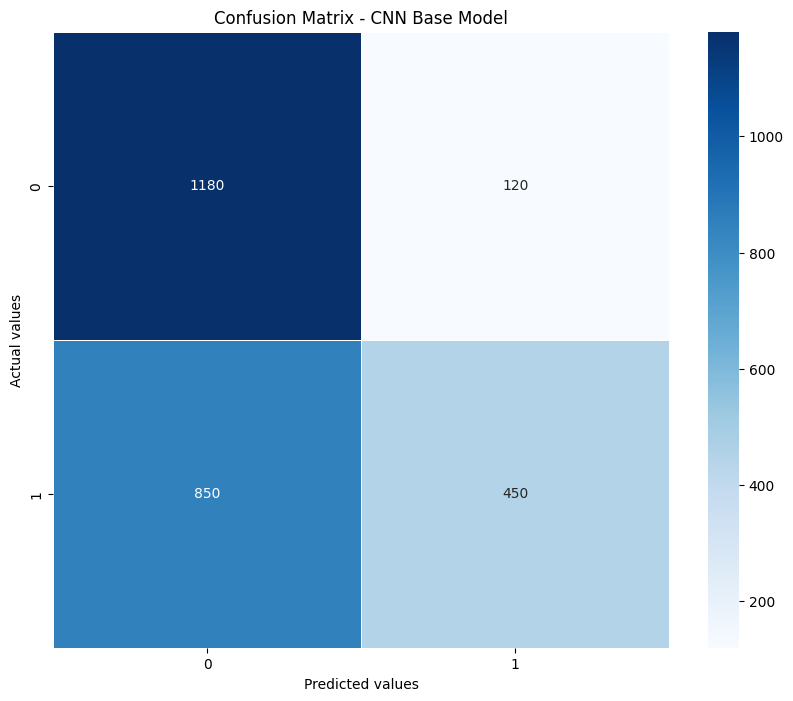

False Negatives (parasitized predicted as uninfected): 850
False Positives (uninfected predicted as parasitized): 120


In [ ]:
# .predict calculates probability vectors

# np.argmax returns the index of the highest probability
# this index corresponds to the predicted/true class (0-1)
# axis=1 ensures argmax operates row by row (per image)

# The confusion matrix compares true vs predicted labels
# Rows represent actual classes (0-1)
# Columns represent predicted classes (0-1)
# Diagonal values = correct predictions
# Off-diagonal values = misclassifications
# tf.math.confusion_matrix(labels, predictions) convention:
# first argument is true labels, second is predicted labels

# sns.heatmap displays the confusion matrix as a heatmap
# annot=True - Display numerical values in each cell
# linewidths=.4 Add thin lines between cells for readability
# fmt="d" - Format values as integers
# square=True - Force square cells for visual clarity
# ax=ax - Plot on the defined axes

test_pred = cnn_model_base.predict(test_images_norm)

test_pred_arg=np.argmax(test_pred,axis=1)
test_labels_arg=np.argmax(test_labels_encoded,axis=1)

confusion_matrix = tf.math.confusion_matrix(test_labels_arg,test_pred_arg)


f, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt="d",
    square=True,
    ax=ax,
    cmap='Blues'
)
plt.title('Confusion Matrix - CNN Base Model')
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.show()

# Extracting FN and FP directly from the confusion matrix
# confusion_matrix[actual][predicted]
# FN: parasitized cells predicted as uninfected (actual=1, predicted=0)
# FP: uninfected cells predicted as parasitized (actual=0, predicted=1)
FN_base = confusion_matrix[1][0].numpy()
FP_base = confusion_matrix[0][1].numpy()
print(f'False Negatives (parasitized predicted as uninfected): {FN_base}')
print(f'False Positives (uninfected predicted as parasitized): {FP_base}')

In [ ]:
# Prints the classification report for cnn_model_base on the test dataset
# The report provides per-class performance metrics:
# - Precision: of all predictions for class 0 or 1, how many were correct?
#   Formula: TP / (TP + FP)
# - Recall: of all actual class 0 or 1, how many did the model catch?
#   Formula: TP / (TP + FN)
# - F1-score: harmonic mean of precision and recall
#   Formula: 2 * (precision * recall) / (precision + recall)
#   Balances both metrics into a single score per class
# - Support: number of actual samples of each class in the test set

report_base = classification_report(test_labels_arg, test_pred_arg)
print("Test Classification Report for Base Model:")
print(report_base)

Test Classification Report for Base Model:
              precision    recall  f1-score   support

           0       0.58      0.91      0.71      1300
           1       0.79      0.35      0.48      1300

    accuracy                           0.63      2600
   macro avg       0.69      0.63      0.59      2600
weighted avg       0.69      0.63      0.59      2600



<b>Plotting the train and validation curves

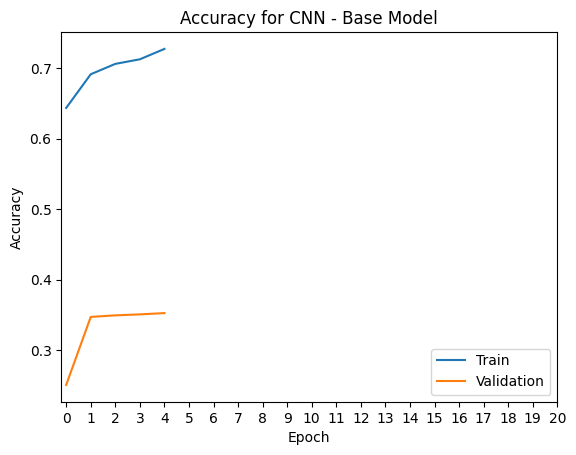

In [ ]:
# Plot training and validation accuracy curves across all 20 epochs
plt.plot(history_base.history['accuracy'])
plt.plot(history_base.history['val_accuracy'])
plt.title('Accuracy for CNN - Base Model')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.xticks(range(0,21))
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

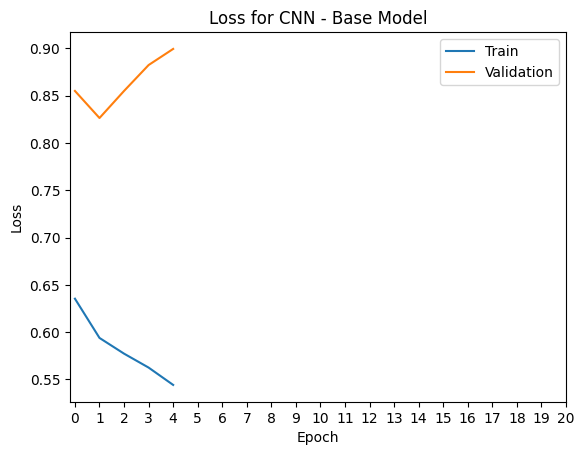

In [ ]:
# Plot training and validation loss curves for the base model
plt.plot(history_base.history['loss'])
plt.plot(history_base.history['val_loss'])
plt.title('Loss for CNN - Base Model')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.xticks(range(0, 21))
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

### **Observations and Insights:**

*Architecture:*

The base model is a simple CNN with 3 convolutional blocks. Each block contains one Conv2D layer with ReLU activation, followed by MaxPooling2D to reduce the spatial dimensions and Dropout(0.2) to limit overfitting. The number of filters is 16 across all three blocks, this is a deliberate choice to keep the model simple and establish a performance baseline. After flattening, a Dense(256) layer maps the 1,024 extracted features to the output layer. The model is very lightweight with only 268,002 trainable parameters (1.02 MB).

*Training:*

The model was compiled with the Adam optimizer (lr=0.0001) and categorical cross-entropy loss, trained for 20 epochs with EarlyStopping (patience=3) but the model converged after 5 epochs.

*Accuracy and loss:*

The model achieved a poor test accuracy of 62.69% with a test loss of 0.6458, with training accuracy reaching ~73% while validation accuracy reached not more than around 35%, indicating a complete failure to generalise.

*Confusion matrix:*

The model produced 850 False Negatives and 120 False Positives, showing a strong bias toward predicting uninfected cells and missing the vast majority of parasitized ones. The numbers are very bad in general and this model can't be used in a medical setting with such results.

*Classification report:*

Precision for the uninfected class is 0.58, while for parasitized class is 0.79
Recall for the parasitized class is only 0.35, while uninfected recall is 0.91, confirming the model's failure to detect infected cells reliably with an overall macro F1 of 0.59.

So now let's try to build another model with few more add on layers and try to check if we can try to improve the model. Therefore try to build a model by adding few layers if required and altering the activation functions.

###<b> Model 1
####<b> Trying to improve the performance of our model by adding new layers


In [ ]:
# Session clearing before model training
backend.clear_session()

# Setting a seed to ensure we have reproducible results
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

###<b> Building the Model

In [ ]:
# Here are listed only the changes compared to cnn_model_base
# Double every conv2D layer compared to the base model
# Filters are changed for each Conv2D layer: 16 - 32 - 64
# The last Dropout layer is added to deactivate 50% of neurons

def cnn_model_1():
  cnn_model = Sequential()

  cnn_model.add(Conv2D(filters = 16, kernel_size = 3, padding = "same", activation = "relu", input_shape = (64, 64, 3)))
  cnn_model.add(Conv2D(filters = 16, kernel_size = 3, padding = "same", activation = "relu"))
  cnn_model.add(MaxPooling2D((2, 2)))

  cnn_model.add(Dropout(0.2))

  cnn_model.add(Conv2D(filters = 32, kernel_size = 3, padding = "same", activation = "relu"))
  cnn_model.add(Conv2D(filters = 32, kernel_size = 3, padding = "same", activation = "relu"))
  cnn_model.add(MaxPooling2D((2, 2)))

  cnn_model.add(Dropout(0.2))

  cnn_model.add(Conv2D(filters = 64, kernel_size = 3, padding = "same", activation = "relu"))
  cnn_model.add(Conv2D(filters = 64, kernel_size = 3, padding = "same", activation = "relu"))
  cnn_model.add(MaxPooling2D((2, 2)))

  cnn_model.add(Dropout(0.2))

  cnn_model.add(Flatten())

  cnn_model.add(Dense(256, activation='relu'))

  cnn_model.add(Dropout(0.5))

  cnn_model.add(Dense(2, activation='softmax'))

  return cnn_model

# Model initialisation
cnn_model_1 = cnn_model_1()

cnn_model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121,426 (4.28 MB)

 Trainable params: 1,121,426 (4.28 MB)

 Non-trainable params: 0 (0.00 B)

###<b> Compiling the model

In [ ]:
# Optimiser Adam and loss with learning rate = 0.0001

opt = Adam(learning_rate=0.0001)
cnn_model_1.compile(optimizer=opt,
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

<b> Using Callbacks

In [ ]:
# callbacks for best_model1
callbacks1 = [EarlyStopping(monitor = 'val_loss', patience = 3),
             ModelCheckpoint('best_model1.keras', monitor = 'val_loss', save_best_only = True)]

<b>Fit and Train the model

In [ ]:
# history1
# For a detailed explanation of the code lines, please refer to the history_base code cell

history1 = cnn_model_1.fit(
    train_images_norm, train_labels_encoded,
    epochs=20,
    validation_split=0.2,
    shuffle=True,
    batch_size=64,
    verbose=1,
    callbacks=callbacks1
)

Epoch 1/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.6460 - loss: 0.6359 - val_accuracy: 0.2618 - val_loss: 0.9628
Epoch 2/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7004 - loss: 0.5778 - val_accuracy: 0.3716 - val_loss: 0.9438
Epoch 3/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7823 - loss: 0.4510 - val_accuracy: 0.8846 - val_loss: 0.3455
Epoch 4/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9256 - loss: 0.1753 - val_accuracy: 0.9339 - val_loss: 0.1911
Epoch 5/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9488 - loss: 0.1318 - val_accuracy: 0.9503 - val_loss: 0.1741
Epoch 6/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9584 - loss: 0.1155 - val_accuracy: 0.9463 - val_loss: 0.1509
Epoch 7/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9658 - loss: 0.1026 - val_accuracy: 0.9585 - val_loss: 0.1133
Epoch 8/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9716 - loss: 0.0905 - val_acc

###<b> Evaluating the model

In [ ]:
# Calculating accuracy after evaluation on the test dataset

accuracy1 = cnn_model_1.evaluate(test_images_norm, test_labels_encoded, verbose = 1)
print('Test_Accuracy: ', accuracy1[1])

82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9865 - loss: 0.0489
Test_Accuracy:  0.9865384697914124


<b> Plotting the confusion matrix

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


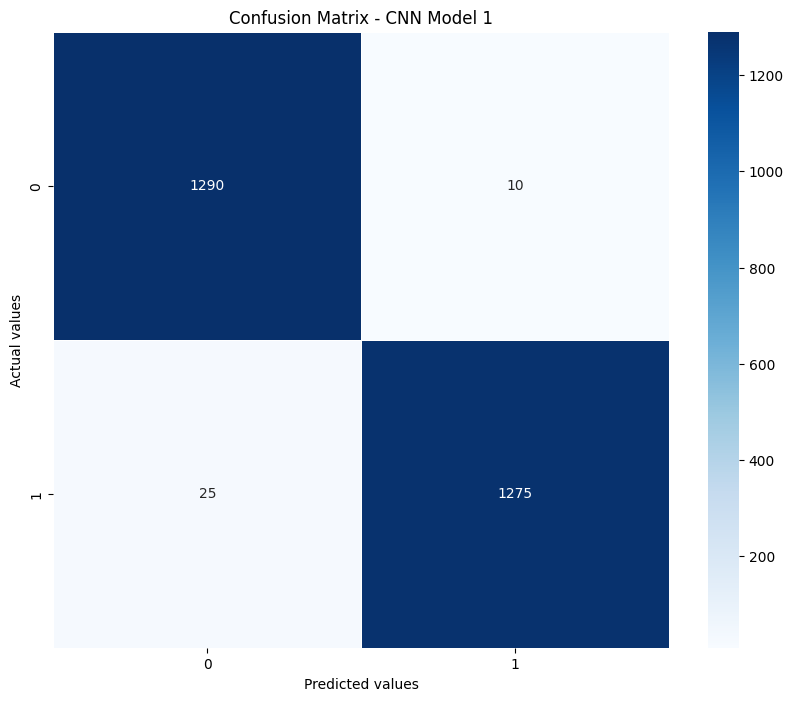

False Negatives (parasitized predicted as uninfected): 25
False Positives (uninfected predicted as parasitized): 10


In [ ]:
# For a detailed explanation of each line of code refer to cnn_model_base confusion matrix

test_pred = cnn_model_1.predict(test_images_norm)

test_pred_arg=np.argmax(test_pred,axis=1)
test_labels_arg=np.argmax(test_labels_encoded,axis=1)

confusion_matrix = tf.math.confusion_matrix(test_labels_arg,test_pred_arg)

f, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt="d",
    square=True,
    ax=ax,
    cmap='Blues'
)
plt.title('Confusion Matrix - CNN Model 1')
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.show()

# Extracting FN and FP directly from the confusion matrix
# confusion_matrix[actual][predicted]
# FN: parasitized cells predicted as uninfected (actual=1, predicted=0)
# FP: uninfected cells predicted as parasitized (actual=0, predicted=1)
FN_model1 = confusion_matrix[1][0].numpy()
FP_model1 = confusion_matrix[0][1].numpy()
print(f'False Negatives (parasitized predicted as uninfected): {FN_model1}')
print(f'False Positives (uninfected predicted as parasitized): {FP_model1}')

In [ ]:
# For a detailed explanation of each line of code refer to cnn_model_base confusion matrix

report_model1 = classification_report(test_labels_arg, test_pred_arg)
print("Test Classification Report for Model 1:")
print(report_model1)

Test Classification Report for Model 1:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1300
           1       0.99      0.98      0.99      1300

    accuracy                           0.99      2600
   macro avg       0.99      0.99      0.99      2600
weighted avg       0.99      0.99      0.99      2600



<b> Plotting the train and the validation curves

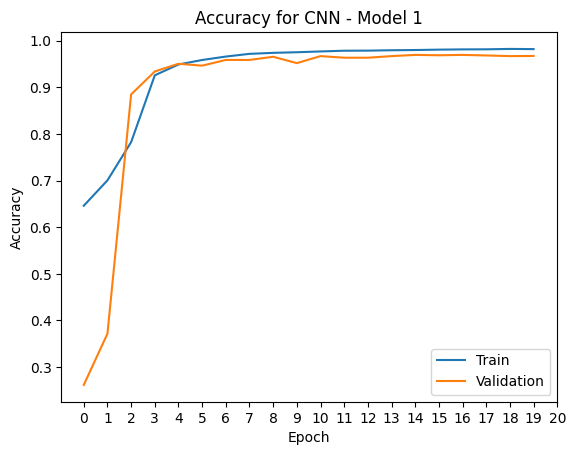

In [ ]:
# Plot training and validation accuracy curves across all 20 epochs
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.title('Accuracy for CNN - Model 1')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.xticks(range(0,21))
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

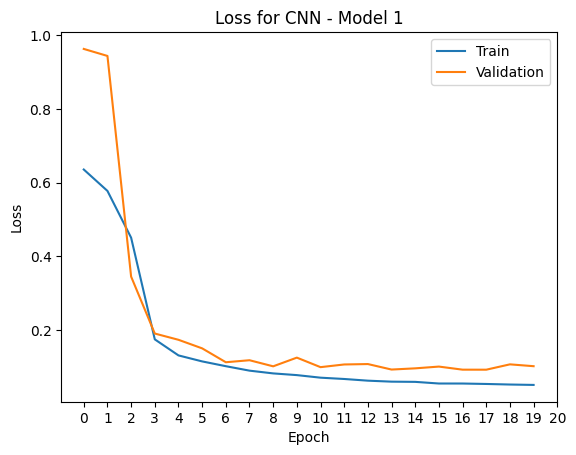

In [ ]:
# Plot training and validation loss curves for the model 1
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.title('Loss for CNN - Model 1')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.xticks(range(0, 21))
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

### **Observations and Insights:**

*Architecture:*

Model 1 deepens the base model by doubling to 2 Conv2D layers per block with progressively increasing filters (16 - 32 - 64), adding a 50% Dropout after the Dense layer, resulting in 1,121,426 trainable parameters (4.28 MB).

*Training:*

Same compilation and callbacks as the base model, training over 20 epochs was stable, with a strong improvement already visible from epoch 3 where validation accuracy jumped from ~37% to ~88%.

*Accuracy and loss:*

The model achieved a test accuracy of 98.65% and test loss of 0.0489, with both training and validation loss decreasing consistently across all 20 epochs and no signs of overfitting.

*Confusion matrix:*

The model produced only 25 False Negatives and 10 False Positives, a dramatic improvement over the base model across both error types. The False Negatives score could be considered still not satisfying in a medical setting but the improvement is considerable over the base model.

*Classification report:*

Both classes achieved a precision, recall, and F1-score of 0.98 to 0.99, with a macro average F1 of 0.99, reflecting a well-balanced and highly accurate model.

###<b>Think about it:</b><br>
Now let's build a model with LeakyRelu as the activation function  

*  Can the model performance be improved if we change our activation function to LeakyRelu?
*  Can BatchNormalization improve our model?

Let us try to build a model using BatchNormalization and using LeakyRelu as our activation function.

###<b> Model 2 with Batch Normalization

In [ ]:
# Session clearing before model training
backend.clear_session()

# Setting a seed to ensure we have reproducible results
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

###<b> Building the Model

In [ ]:
# The activation function used is LeakyReLu instead of ReLu for the Conv2D layers
# BatchNormalization layer is added after each Conv2D
# It acts as a mild regularisation after Conv2D

def cnn_model_2():
  cnn_model = Sequential()

  cnn_model.add(Conv2D(filters = 16, kernel_size = 3, padding='same', input_shape=(64, 64, 3)))
  cnn_model.add(LeakyReLU(alpha=0.1))
  cnn_model.add(Conv2D(filters = 16, kernel_size = 3, padding='same'))
  cnn_model.add(LeakyReLU(alpha=0.1))
  cnn_model.add(MaxPooling2D((2, 2)))

  cnn_model.add(BatchNormalization())

  cnn_model.add(Dropout(0.2))

  cnn_model.add(Conv2D(filters = 32, kernel_size = 3, padding='same'))
  cnn_model.add(LeakyReLU(alpha=0.1))
  cnn_model.add(Conv2D(filters = 32, kernel_size = 3, padding='same'))
  cnn_model.add(LeakyReLU(alpha=0.1))
  cnn_model.add(MaxPooling2D((2, 2)))

  cnn_model.add(BatchNormalization())

  cnn_model.add(Dropout(0.2))

  cnn_model.add(Conv2D(filters = 64, kernel_size = 3, padding='same'))
  cnn_model.add(LeakyReLU(alpha=0.1))
  cnn_model.add(Conv2D(filters = 64, kernel_size = 3, padding='same'))
  cnn_model.add(LeakyReLU(alpha=0.1))
  cnn_model.add(MaxPooling2D((2, 2)))

  cnn_model.add(BatchNormalization())

  cnn_model.add(Dropout(0.2))

  cnn_model.add(Flatten())

  cnn_model.add(Dense(256))
  cnn_model.add(LeakyReLU(alpha=0.1))

  cnn_model.add(Dropout(0.5))

  cnn_model.add(Dense(2, activation='softmax'))

  return cnn_model

cnn_model_2 = cnn_model_2()

cnn_model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,121,874 (4.28 MB)

 Trainable params: 1,121,650 (4.28 MB)

 Non-trainable params: 224 (896.00 B)

###<b>Compiling the model

In [ ]:
# Optimiser Adam and loss with learning rate = 0.0001

opt = Adam(learning_rate=0.0001)
cnn_model_2.compile(optimizer=opt,
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

<b> Using callbacks

In [ ]:
# callbacks for best_model2
callbacks2 = [EarlyStopping(monitor = 'val_loss', patience = 3),
             ModelCheckpoint('best_model2.keras', monitor = 'val_loss', save_best_only = True)]

<b>Fit and train the model

In [ ]:
# history2 is similar to history1

history2 = cnn_model_2.fit(
    train_images_norm, train_labels_encoded,
    epochs=20,
    validation_split=0.2,
    shuffle=True,
    batch_size=64,
    verbose=1,
    callbacks=callbacks2
)

Epoch 1/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - accuracy: 0.6687 - loss: 0.6767 - val_accuracy: 0.0000e+00 - val_loss: 4.4316
Epoch 2/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8107 - loss: 0.4169 - val_accuracy: 0.0445 - val_loss: 6.9776
Epoch 3/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9275 - loss: 0.1961 - val_accuracy: 0.7839 - val_loss: 0.8287
Epoch 4/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9533 - loss: 0.1347 - val_accuracy: 0.8810 - val_loss: 0.4512
Epoch 5/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9631 - loss: 0.1113 - val_accuracy: 0.9183 - val_loss: 0.3085
Epoch 6/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9681 - loss: 0.0979 - val_accuracy: 0.9189 - val_loss: 0.3457
Epoch 7/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9716 - loss: 0.0905 - val_accuracy: 0.8920 - val_loss: 0.5260
Epoch 8/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9746 - loss: 0.0807 - val

<b>Plotting the train and validation accuracy

In [ ]:
# Calculating accuracy after evaluation on the test dataset
accuracy2 = cnn_model_2.evaluate(test_images_norm, test_labels_encoded, verbose = 1)
print('Test_Accuracy: ', accuracy2[1])

82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9677 - loss: 0.1523
Test_Accuracy:  0.9676923155784607


###<b>Evaluating the model

<b> Generate the classification report and confusion matrix

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


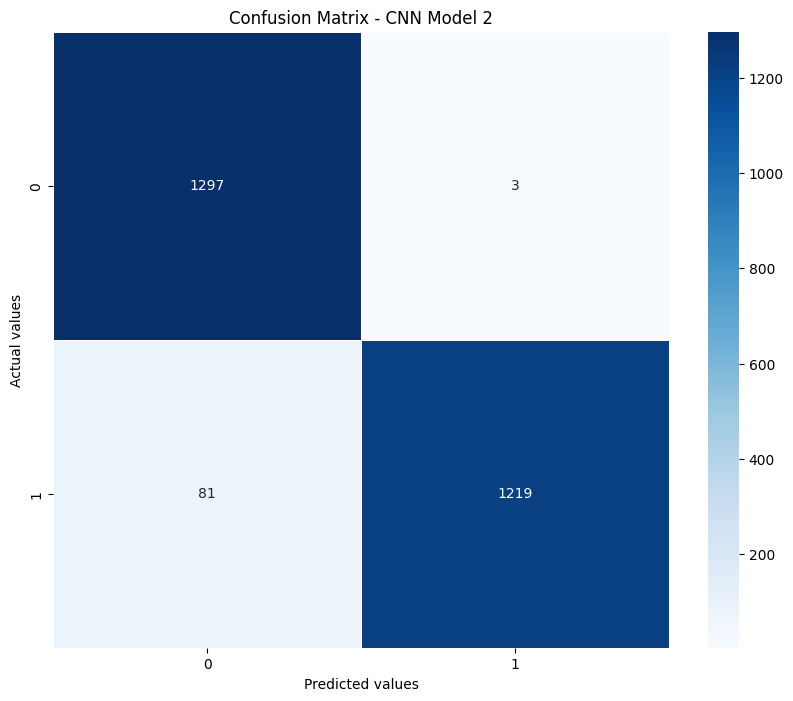

False Negatives (parasitized predicted as uninfected): 81
False Positives (uninfected predicted as parasitized): 3


In [ ]:
# For a detailed explanation of each line of code refer to cnn_model_base confusion matrix

test_pred = cnn_model_2.predict(test_images_norm)

test_pred_arg=np.argmax(test_pred,axis=1)
test_labels_arg=np.argmax(test_labels_encoded,axis=1)

confusion_matrix = tf.math.confusion_matrix(test_labels_arg,test_pred_arg)

f, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt="d",
    square=True,
    ax=ax,
    cmap='Blues'
)
plt.title('Confusion Matrix - CNN Model 2')
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.show()

# Extracting FN and FP directly from the confusion matrix
# confusion_matrix[actual][predicted]
# FN: parasitized cells predicted as uninfected (actual=1, predicted=0)
# FP: uninfected cells predicted as parasitized (actual=0, predicted=1)
FN_model2 = confusion_matrix[1][0].numpy()
FP_model2 = confusion_matrix[0][1].numpy()
print(f'False Negatives (parasitized predicted as uninfected): {FN_model2}')
print(f'False Positives (uninfected predicted as parasitized): {FP_model2}')

In [ ]:
# For a detailed explanation of each line of code refer to cnn_model_base confusion matrix
report_model2 = classification_report(test_labels_arg, test_pred_arg)
print("Test Classification Report for Model 2:")
print(report_model2)

Test Classification Report for Model 2:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1300
           1       1.00      0.94      0.97      1300

    accuracy                           0.97      2600
   macro avg       0.97      0.97      0.97      2600
weighted avg       0.97      0.97      0.97      2600



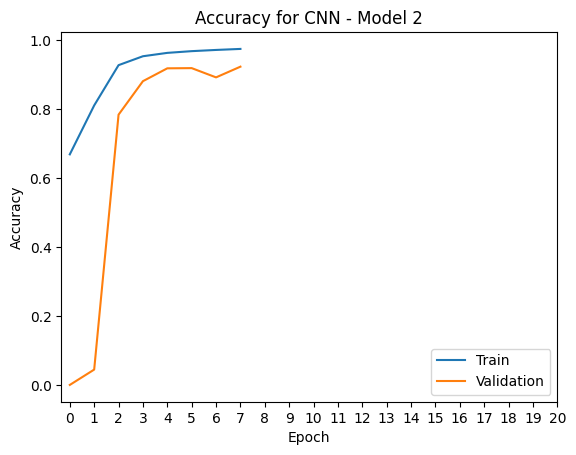

In [ ]:
# Plot training and validation accuracy curves across all 20 epochs
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.title('Accuracy for CNN - Model 2')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.xticks(range(0,21))
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

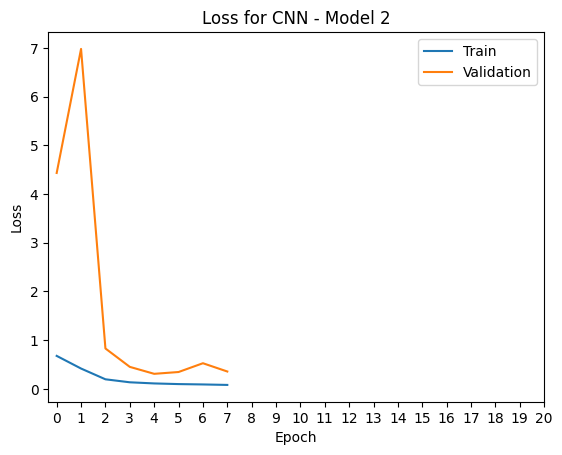

In [ ]:
# Plot training and validation loss curves for the model 2
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title('Loss for CNN - Model 2')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.xticks(range(0, 21))
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

### **Observations and Insights:**

*Architecture:*

 Model 2 shares the same block structure as Model 1 but replaces ReLU with LeakyReLU in all Conv2D layers and adds a BatchNormalization layer after each MaxPooling block with 1,121,650 trainable and 224 non-trainable parameters (4.28 MB total).

*Training:*

EarlyStopping stopped training at only 8 epochs as validation loss stopped improving: validation accuracy crashed at start, starting at 0% in epoch 1 before recovering, suggesting BatchNormalization introduced some gradient flow sensitivity for this dataset.

*Accuracy and loss:*

The model reached a test accuracy of 96.77% and test loss of 0.1523, lower than Model 1, with validation accuracy fluctuating more and peaking around 92%.

*Confusion matrix:*

The model produced 81 False Negatives and only 3 False Positives, showing the model did well in identifying uninfected cells, but at the cost of missing more parasitized ones.

*Classification report:*

Precision for parasitized class reached almost 1.00 (rounded in the classification report) and uninfected recall was almost perfect at 1.00 while parasitized recall dropped to 0.94 with a macro F1 of 0.97, strong overall, but less balanced than Model 1 in its ability to catch infected cells. For a medical setting this model performs worse than model 1.

###**Think About It :**<br>

* Can we improve the model with Image Data Augmentation?
* References to image data augmentation can be seen below:
  *   [Image Augmentation for Computer Vision](https://www.mygreatlearning.com/blog/understanding-data-augmentation/)
  *   [How to Configure Image Data Augmentation in Keras?](https://machinelearningmastery.com/how-to-configure-image-data-augmentation-when-training-deep-learning-neural-networks/)





###<b>Model 3 with Data Augmentation

In [ ]:
# Session clearing before model training
backend.clear_session()

# Setting a seed to ensure we have reproducible results
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

###<b> Use image data generator

In [ ]:
# Splitting the normalised training data into 80% training and 20% validation
# random_state=42 ensures reproducibility of the split across runs
X_train, X_val, y_train, y_val = train_test_split(
    train_images_norm, train_labels_encoded,
    test_size=0.2,
    random_state=42
)

# Defining augmentation transformations applied to training images only
train_datagen = ImageDataGenerator(
    rotation_range=30,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.3
)

# No augmentation on validation data as it must reflect real world conditions
val_datagen = ImageDataGenerator()

# Creating generators that contain augmented batches during training
train_generator = train_datagen.flow(x=X_train, y=y_train, batch_size=64, shuffle=True)
val_generator = val_datagen.flow(x=X_val, y=y_val, batch_size=64, shuffle=False)

###**Think About It :**<br>

*  Check if the performance of the model can be improved by changing different parameters in the ImageDataGenerator.



####<B>Visualizing Augmented images

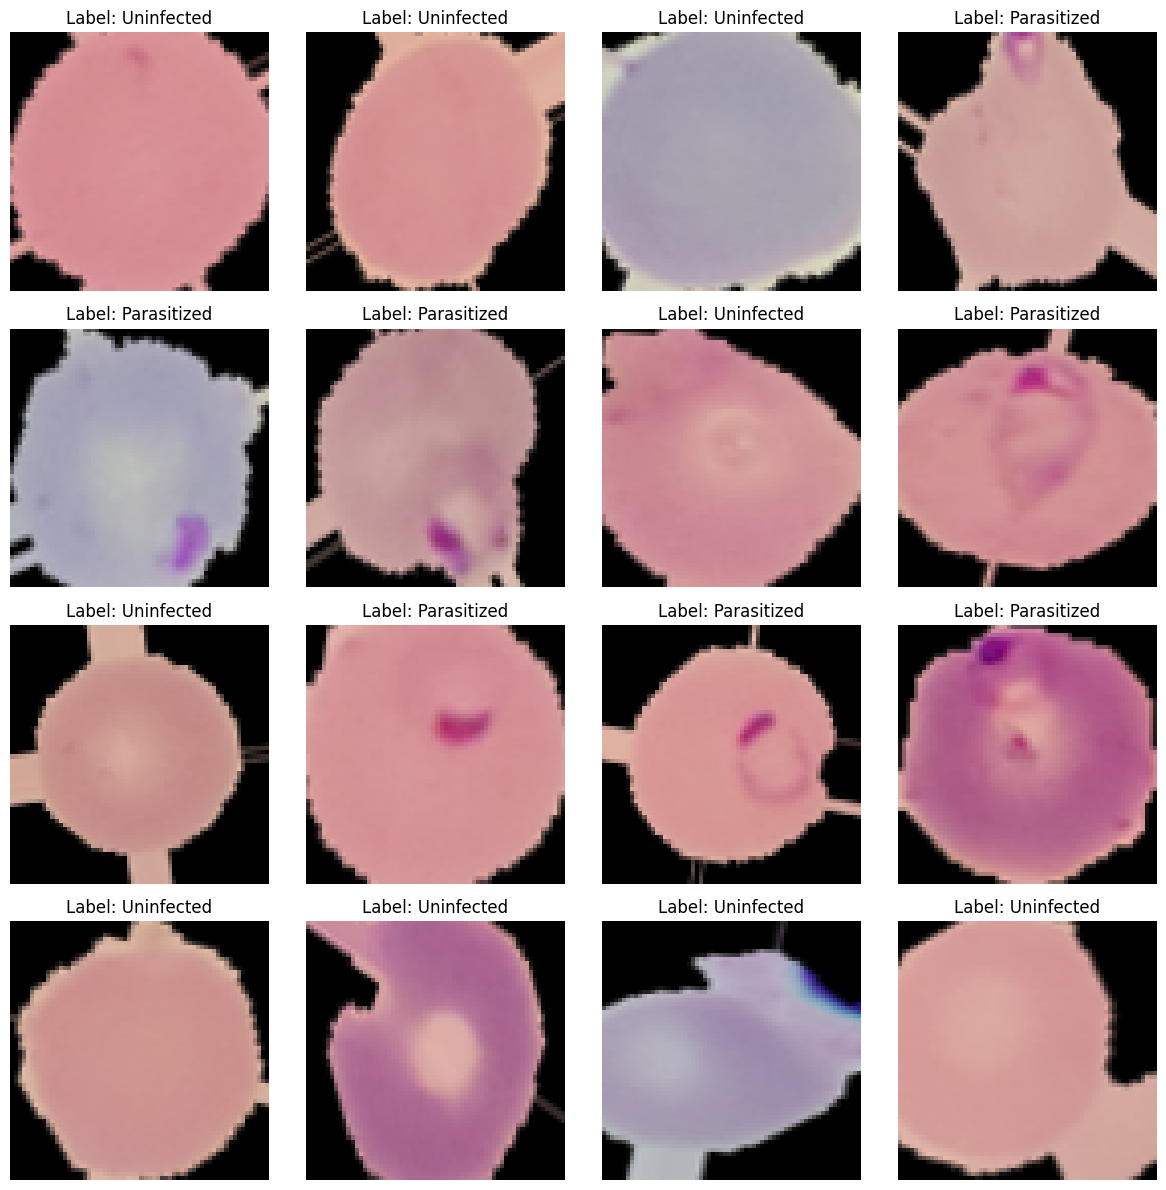

In [ ]:
# Visualising 16 augmented images from the training generator
plt.figure(figsize=(12, 12))

# Fetching one batch of augmented images and labels from the generator
images, labels = next(train_generator)

# Displaying the images in a 4x4 grid with titles
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(images[i])
    plt.title(f'Label: {"Parasitized" if labels[i][1] == 1 else "Uninfected"}')
    plt.axis('off')

plt.tight_layout()
plt.show()

### **Observations and Insights:**

To explore the train dataset after Data Augmentation, we displayed a sample of 16 images of uninfected and parasitized cells.

- The most important observation we can make is in the visual variability for each cell. Some cell pictures have indeed a zoom applied to them. Which confirms that the setting for the Data Augmentation has been correctly applied to the dataset. It is more difficult to tell visually which one has been flipped or rotated.

###<b>Building the Model

In [ ]:
# The model used here is the same as the Model 1 from this notebook
# Please refer to Model 1 for detailed explanation of the code lines

def cnn_model_1gen():
  cnn_model = Sequential()

  cnn_model.add(Conv2D(filters = 16, kernel_size = 3, padding = "same", activation = "relu", input_shape = (64, 64, 3)))
  cnn_model.add(Conv2D(filters = 16, kernel_size = 3, padding = "same", activation = "relu"))
  cnn_model.add(MaxPooling2D((2, 2)))

  cnn_model.add(Dropout(0.2))

  cnn_model.add(Conv2D(filters = 32, kernel_size = 3, padding = "same", activation = "relu"))
  cnn_model.add(Conv2D(filters = 32, kernel_size = 3, padding = "same", activation = "relu"))
  cnn_model.add(MaxPooling2D((2, 2)))

  cnn_model.add(Dropout(0.2))

  cnn_model.add(Conv2D(filters = 64, kernel_size = 3, padding = "same", activation = "relu"))
  cnn_model.add(Conv2D(filters = 64, kernel_size = 3, padding = "same", activation = "relu"))
  cnn_model.add(MaxPooling2D((2, 2)))

  cnn_model.add(Dropout(0.2))

  cnn_model.add(Flatten())

  cnn_model.add(Dense(256, activation='relu'))

  cnn_model.add(Dropout(0.5))

  cnn_model.add(Dense(2, activation='softmax'))

  return cnn_model

# Model initialisation
cnn_model_1gen = cnn_model_1gen()

cnn_model_1gen.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121,426 (4.28 MB)

 Trainable params: 1,121,426 (4.28 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Optimiser Adam and loss with learning rate = 0.0001

opt = Adam(learning_rate=0.0001)
cnn_model_1gen.compile(optimizer=opt,
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

<b>Using Callbacks

In [ ]:
# callbacks for best_model_gen
callbacks_gen = [EarlyStopping(monitor = 'val_loss', patience = 3),
             ModelCheckpoint('best_model_gen.keras', monitor = 'val_loss', save_best_only = True)]

<b> Fit and Train the model

In [ ]:
# history_gen
# For detailed explanation of the code lines, please refer to the history1 code cell

history_gen = cnn_model_1gen.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    verbose=1,
    callbacks=callbacks_gen
)

Epoch 1/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step - accuracy: 0.6054 - loss: 0.6546 - val_accuracy: 0.6679 - val_loss: 0.6200
Epoch 2/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.7532 - loss: 0.5120 - val_accuracy: 0.9022 - val_loss: 0.2317
Epoch 3/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.9107 - loss: 0.2256 - val_accuracy: 0.9549 - val_loss: 0.1239
Epoch 4/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.9386 - loss: 0.1675 - val_accuracy: 0.9698 - val_loss: 0.0964
Epoch 5/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.9529 - loss: 0.1387 - val_accuracy: 0.9690 - val_loss: 0.0906
Epoch 6/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.9587 - loss: 0.1265 - val_accuracy: 0.9762 - val_loss: 0.0764
Epoch 7/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.9615 - loss: 0.1169 - val_accuracy: 0.9782 - val_loss: 0.0669
Epoch 8/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.9654 - loss: 0.1101 - 

###<B>Evaluating the model

In [ ]:
# Calculating accuracy after evaluation on the test dataset
accuracy_gen = cnn_model_1gen.evaluate(test_images_norm, test_labels_encoded, verbose = 1)
print('Test_Accuracy: ', accuracy_gen[1])

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9881 - loss: 0.0423
Test_Accuracy:  0.98807692527771


<B>Plotting the classification report and confusion matrix

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


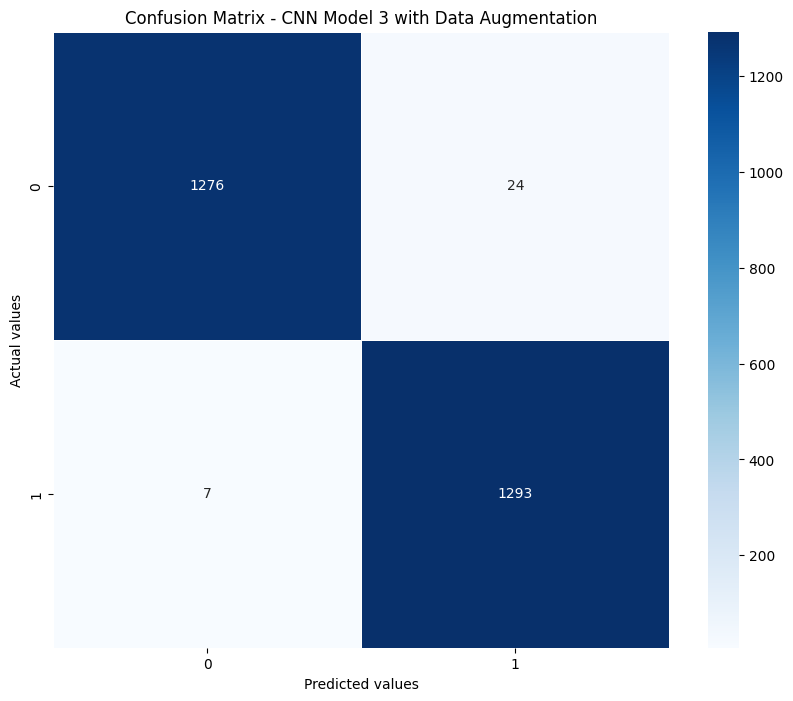

False Negatives (parasitized predicted as uninfected): 7
False Positives (uninfected predicted as parasitized): 24


In [ ]:
# For a detailed explanation of each line of code refer to cnn_model_base confusion matrix

test_pred = cnn_model_1gen.predict(test_images_norm)

test_pred_arg=np.argmax(test_pred,axis=1)
test_labels_arg=np.argmax(test_labels_encoded,axis=1)

confusion_matrix = tf.math.confusion_matrix(test_labels_arg,test_pred_arg)

f, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt="d",
    square=True,
    ax=ax,
    cmap='Blues'
)
plt.title('Confusion Matrix - CNN Model 3 with Data Augmentation')
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.show()

# Extracting FN and FP directly from the confusion matrix
# confusion_matrix[actual][predicted]
# FN: parasitized cells predicted as uninfected (actual=1, predicted=0)
# FP: uninfected cells predicted as parasitized (actual=0, predicted=1)
FN_gen = confusion_matrix[1][0].numpy()
FP_gen = confusion_matrix[0][1].numpy()
print(f'False Negatives (parasitized predicted as uninfected): {FN_gen}')
print(f'False Positives (uninfected predicted as parasitized): {FP_gen}')

In [ ]:
# For a detailed explanation of each line of code refer to cnn_model_base confusion matrix
report_gen = classification_report(test_labels_arg, test_pred_arg)
print("Test Classification Report for the Model 3 with Data Augmentation:")
print(report_gen)

Test Classification Report for the Model 3 with Data Augmentation:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1300
           1       0.98      0.99      0.99      1300

    accuracy                           0.99      2600
   macro avg       0.99      0.99      0.99      2600
weighted avg       0.99      0.99      0.99      2600



<b>Plot the train and validation accuracy

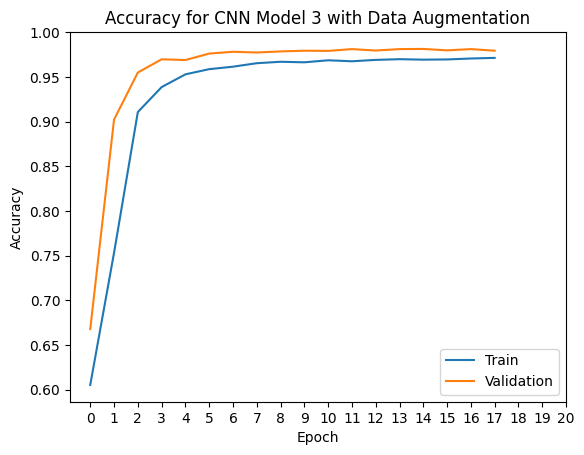

In [ ]:
# Plot training and validation accuracy curves across all 20 epochs
plt.plot(history_gen.history['accuracy'])
plt.plot(history_gen.history['val_accuracy'])
plt.title('Accuracy for CNN Model 3 with Data Augmentation')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.xticks(range(0,21))
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

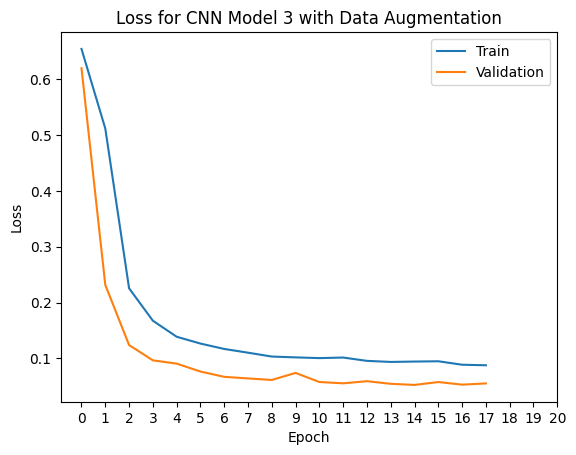

In [ ]:
# Plot training and validation loss curves for the data augmentation model
plt.plot(history_gen.history['loss'])
plt.plot(history_gen.history['val_loss'])
plt.title('Loss for CNN Model 3 with Data Augmentation')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.xticks(range(0, 21))
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

### **Observations and Insights:**

*Architecture:*

Model 3 uses the exact same architecture as Model 1. The key difference is not in the architecture but in the training data.

*Training:*

An ImageDataGenerator was used to apply online data augmentation to the training set only, with the following transformations: random rotations up to 30°, horizontal and vertical flips, and zoom up to 30%. The validation data was not augmented. The training set was further split into 80% training and 20% validation before generating the augmented batches. The model trained for 18 epochs. Training was slower per epoch compared to Model 1, as augmented images are generated on the fly during training, which increases computational effort.

*Accuracy and loss:*

The model achieved a test accuracy of 98.81% with a test loss of 0.0423, the best test accuracy of all trained models. Training accuracy reached 97.1% and validation accuracy reached 98.1%, with both loss curves decreasing smoothly. The training and validation curves align very closely, indicating that the augmentation helped the model generalise well and reduced overfitting.

*Confusion matrix:*

The model produced only 7 False Negatives and 24 False Positives. With the lowest false negative count of all models, this model is best at detecting every single parasitized cell, even at the cost of slightly more false positives. In a medical setting, this is the most desirable trade-off, as missing an infected cell is more dangerous than raising a false alarm.

*Classification report:*

The recall for the parasitized class is 0.99, the highest of all models, reflecting the model's exceptional ability to catch infected cells. This model was ultimately selected as the final saved model.

<b> Now, let us try to use a pretrained model like VGG16 and check how it performs on our data.

### **Pre-trained model (VGG16)**
- Import VGG16 network upto any layer you choose
- Add Fully Connected Layers on top of it

In [ ]:
# Session clearing before model training
backend.clear_session()

# Setting a seed to ensure we have reproducible results
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Loading VGG16 with pre-trained ImageNet weights
# include_top=False : custom layers added on top
# input_shape=(64, 64, 3) : keeping our original image dimensions
vgg = VGG16(include_top=False, weights='imagenet', input_shape=(64, 64, 3))

# Extracting the output from block4_pool to preserve more spatial information
# With 64x64 input, block4_pool gives 4x4x512 = 8192 features
transfer_layer = vgg.get_layer('block4_pool')

# Freezing all VGG16 layers - weights stay fixed from ImageNet training
vgg.trainable = False

# Building the custom classification head
x = Flatten()(transfer_layer.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
pred = Dense(2, activation='softmax')(x)

# Initialising the model with VGG16 input and custom output
model_vgg = Model(vgg.input, pred)

model_vgg.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,733,186 (37.13 MB)

 Trainable params: 2,097,922 (8.00 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

###<b>Compiling the model

In [ ]:
# Optimiser Adam and loss with learning rate = 0.0001

opt = Adam(learning_rate=0.0001)
model_vgg.compile(optimizer=opt,
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

<b> using callbacks

In [ ]:
# callbacks for best_model_vgg
callbacks_vgg = [EarlyStopping(monitor = 'val_loss', patience = 3),
             ModelCheckpoint('best_model_vgg.keras', monitor = 'val_loss', save_best_only = True)]

<b>Fit and Train the model

In [ ]:
# history_vgg
# For detailed explanation of the code lines, please refer to the history1 code cell

history_vgg = model_vgg.fit(
    train_images_norm, train_labels_encoded,
    epochs=20,
    validation_split=0.2,
    shuffle=True,
    batch_size=64,
    verbose=1,
    callbacks=callbacks_vgg
)

Epoch 1/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 26s 65ms/step - accuracy: 0.8874 - loss: 0.3822 - val_accuracy: 0.8806 - val_loss: 0.2887
Epoch 2/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.9470 - loss: 0.1504 - val_accuracy: 0.8958 - val_loss: 0.2612
Epoch 3/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.9578 - loss: 0.1219 - val_accuracy: 0.9165 - val_loss: 0.2143
Epoch 4/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.9646 - loss: 0.1030 - val_accuracy: 0.9197 - val_loss: 0.2134
Epoch 5/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.9701 - loss: 0.0911 - val_accuracy: 0.9367 - val_loss: 0.1610
Epoch 6/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.9711 - loss: 0.0873 - val_accuracy: 0.9217 - val_loss: 0.2182
Epoch 7/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.9739 - loss: 0.0796 - val_accuracy: 0.9349 - val_loss: 0.1756
Epoch 8/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.9765 - loss: 0.0749 - 

In [ ]:
# Calculating accuracy after evaluation on the test dataset
accuracy_vgg = model_vgg.evaluate(test_images_norm, test_labels_encoded, verbose = 1)
print('Test_Accuracy: ', accuracy_vgg[1])

82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9658 - loss: 0.0985
Test_Accuracy:  0.9657692313194275


<b>Plot the train and validation accuracy

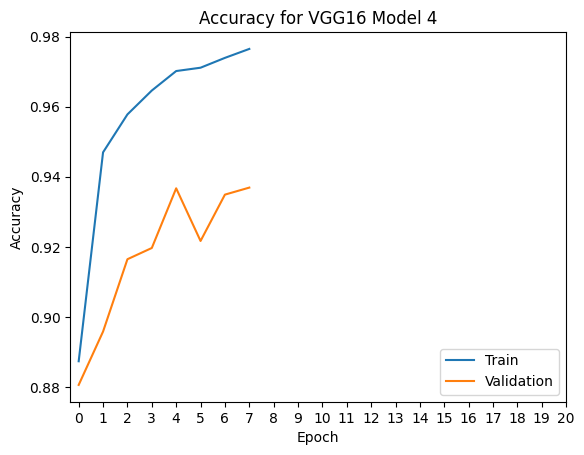

In [ ]:
# Plot training and validation accuracy curves across all 20 epochs
plt.plot(history_vgg.history['accuracy'])
plt.plot(history_vgg.history['val_accuracy'])
plt.title('Accuracy for VGG16 Model 4')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.xticks(range(0,21))
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

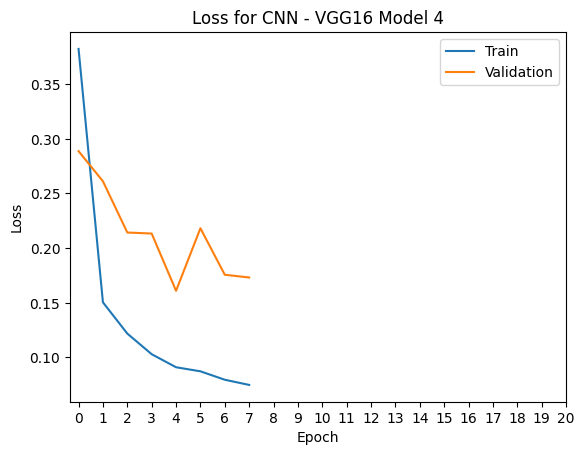

In [ ]:
# Plot training and validation loss curves for the VGG16 model 4
plt.plot(history_vgg.history['loss'])
plt.plot(history_vgg.history['val_loss'])
plt.title('Loss for CNN - VGG16 Model 4')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.xticks(range(0, 21))
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

### **Observations and Insights:**

*   What can be observed from the validation and train curves?

The training accuracy increases from 88% at epoch 1 to 97% at epoch 8 which is the sign of consistent learning but validation accuracy however is stuck between 92% and 94% after epoch 3. The gap seems to increase between both curves, a clear sign of overfitting.

The training loss decreases smoothly which is a confirmation of consistent learning however validation loss is unstable. The gap between both curves confirms overfitting.

###<b> Evaluating the model

<b>Plotting the classification report and confusion matrix

82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


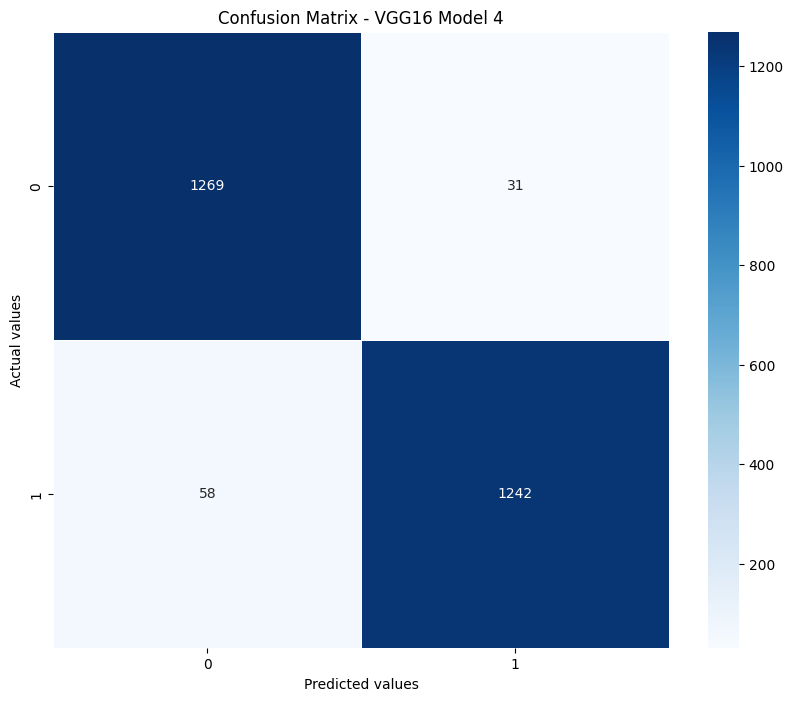

False Negatives (parasitized predicted as uninfected): 58
False Positives (uninfected predicted as parasitized): 31


In [ ]:
# For a detailed explanation of each line of code refer to cnn_model_base confusion matrix

test_pred = model_vgg.predict(test_images_norm)

test_pred_arg=np.argmax(test_pred,axis=1)
test_labels_arg=np.argmax(test_labels_encoded,axis=1)

confusion_matrix = tf.math.confusion_matrix(test_labels_arg,test_pred_arg)

f, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt="d",
    square=True,
    ax=ax,
    cmap='Blues'
)
plt.title('Confusion Matrix - VGG16 Model 4')
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.show()

# Extracting FN and FP directly from the confusion matrix
# confusion_matrix[actual][predicted]
# FN: parasitized cells predicted as uninfected (actual=1, predicted=0)
# FP: uninfected cells predicted as parasitized (actual=0, predicted=1)
FN_vgg = confusion_matrix[1][0].numpy()
FP_vgg = confusion_matrix[0][1].numpy()
print(f'False Negatives (parasitized predicted as uninfected): {FN_vgg}')
print(f'False Positives (uninfected predicted as parasitized): {FP_vgg}')

In [ ]:
# For a detailed explanation of each line of code refer to cnn_model_base confusion matrix
report_vgg = classification_report(test_labels_arg, test_pred_arg)
print("Test Classification Report for the VGG16 Model 4:")
print(report_vgg)

Test Classification Report for the VGG16 Model 4:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1300
           1       0.98      0.96      0.97      1300

    accuracy                           0.97      2600
   macro avg       0.97      0.97      0.97      2600
weighted avg       0.97      0.97      0.97      2600



###<b>Think about it:</b>
*  What observations and insights can be drawn from the confusion matrix and classification report?
*  Choose the model with the best accuracy scores from all the above models and save it as a final model.


### **Observations and Insights:**

*Architecture:*

Model 4 uses the first 4 convolutional blocks of VGG16 (pre-trained on ImageNet) with frozen feature layers and with custom layers on top of it: Flatten -> Dense(256) -> 50% Dropout -> Dense(2) with softmax, totalling 9,733,186 parameters (37.13 MB).

*Training:*

EarlyStopping stopped training after 8 epochs. Unlike the custom models, the VGG16 base gave a high starting accuracy of 88.7% from epoch 1 thanks to its pre-learned ImageNet features, but validation accuracy plateaued around 93 to 94% with some oscillation.

*Accuracy and loss:*

Additionally to the previous observation made under the curve graphs for this model: the model is performing worse than the previous custom CNNs despite its much larger size, likely due to the domain gap between natural ImageNet photographs and microscopic cell images and potentially the fact that the original VGG16 model takes pictures of much larger size (224x224) as inputs.

*Confusion matrix:*

The model produced 58 False Negatives and 31 False Positives, the highest combined error count among the well-performing models (Model 1 and Model 2 included), indicating that frozen ImageNet features did not transfer as effectively to this medical imaging task.

*Classification report:*

Both classes achieved an F1-score of 0.97 with a macro average of 0.97, but the parasitized recall of 0.96 is the lowest among the better-performing models, making this model less suited for a medical setting despite its architectural sophistication.

####<b> Observations and Conclusions drawn from the final model:


In [ ]:
# Model performance comparison table
results = {
    'Model': ['Base Model', 'Model 1', 'Model 2', 'Model 3 (Augmentation)', 'Model 4 (VGG16)'],
    'Test Accuracy (%)': [
        round(accuracy_base[1] * 100, 2),
        round(accuracy1[1] * 100, 2),
        round(accuracy2[1] * 100, 2),
        round(accuracy_gen[1] * 100, 2),
        round(accuracy_vgg[1] * 100, 2)
    ],
    'False Negatives': [FN_base, FN_model1, FN_model2, FN_gen, FN_vgg],
    'False Positives': [FP_base, FP_model1, FP_model2, FP_gen, FP_vgg]
}

results_df = pd.DataFrame(results)
#results_df = results_df.sort_values('Test Accuracy (%)', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

                 Model  Test Accuracy (%)  False Negatives  False Positives
            Base Model              62.69              850              120
               Model 1              98.65               25               10
               Model 2              96.77               81                3
Model 3 (Augmentation)              98.81                7               24
       Model 4 (VGG16)              96.58               58               31


In [ ]:
# Comparing classification reports for all models in a single output
models = {
    'Base Model': report_base,
    'Model 1': report_model1,
    'Model 2': report_model2,
    'Model 3 - Data Augmentation': report_gen,
    'Model 4 - VGG16': report_vgg
}

for model_name, report in models.items():
    print(f'{"="*50}')
    print(f'Classification Report - {model_name}')
    print(f'{"="*50}')
    print(report)
    print()

Classification Report - Base Model
              precision    recall  f1-score   support

           0       0.58      0.91      0.71      1300
           1       0.79      0.35      0.48      1300

    accuracy                           0.63      2600
   macro avg       0.69      0.63      0.59      2600
weighted avg       0.69      0.63      0.59      2600


Classification Report - Model 1
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1300
           1       0.99      0.98      0.99      1300

    accuracy                           0.99      2600
   macro avg       0.99      0.99      0.99      2600
weighted avg       0.99      0.99      0.99      2600


Classification Report - Model 2
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1300
           1       1.00      0.94      0.97      1300

    accuracy                           0.97      2600
   macro avg       0.97    

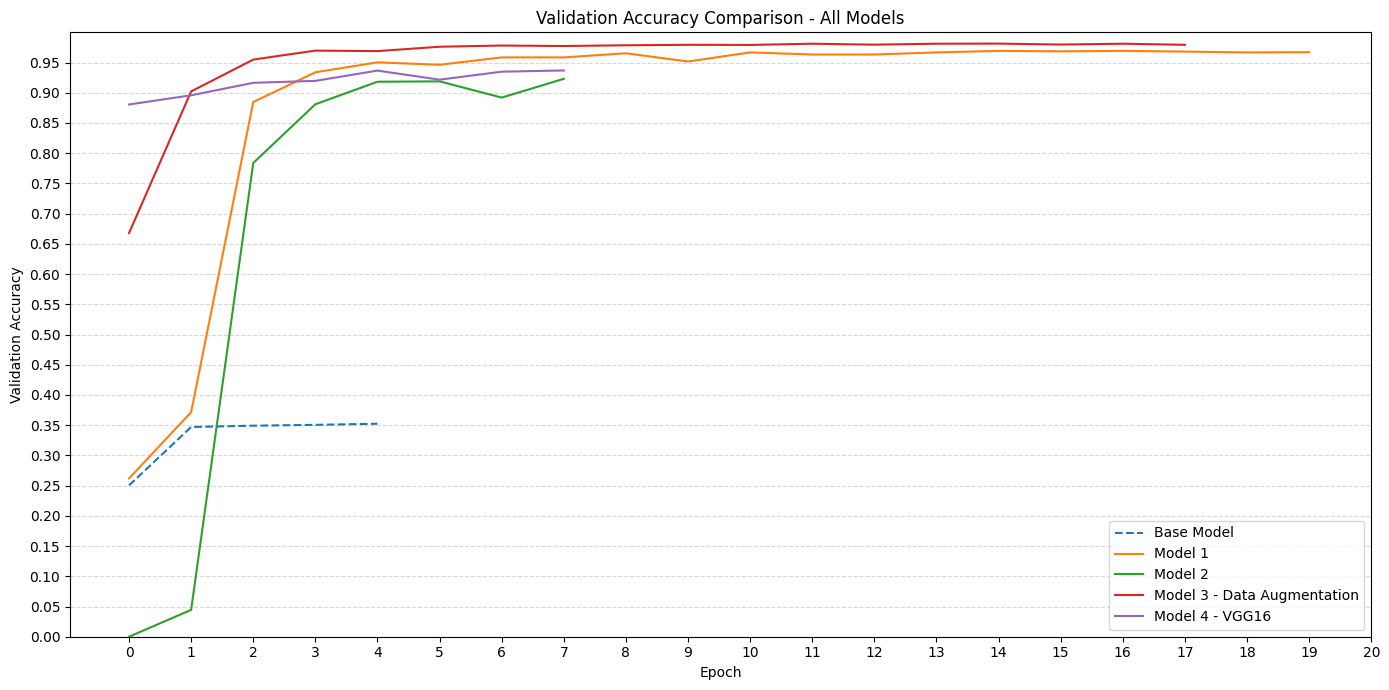

In [ ]:
# Plotting all model accuracy curves on the same figure for comparison
plt.figure(figsize=(14, 7))

plt.plot(history_base.history['val_accuracy'], label='Base Model', linestyle='--')
plt.plot(history1.history['val_accuracy'], label='Model 1')
plt.plot(history2.history['val_accuracy'], label='Model 2')
plt.plot(history_gen.history['val_accuracy'], label='Model 3 - Data Augmentation')
plt.plot(history_vgg.history['val_accuracy'], label='Model 4 - VGG16')

plt.title('Validation Accuracy Comparison - All Models')
plt.ylabel('Validation Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.xticks(range(0, 21))

# Setting y-axis to focus on the relevant range
plt.ylim(0, 1.0)

# Adding y-axis ticks
import numpy as np
plt.yticks(np.arange(0, 1, 0.05))

# Adding a grid for easier reading
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# Saving the best model - Model 3 with Data Augmentation
# Selected based on lowest false negatives (7), strong test accuracy (98.81%) and best Recall for parasitized class (0.99)
# In a medical diagnostic context, minimising false negatives is the priority
cnn_model_1gen.save('final_model.keras')
print('Final model saved successfully')

Final model saved successfully


In [ ]:
# Loading and verifying the saved model

final_model = load_model('final_model.keras')
final_accuracy = final_model.evaluate(test_images_norm, test_labels_encoded, verbose=1)
print(f'Final model test accuracy: {final_accuracy[1]*100:.2f}%')

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9881 - loss: 0.0423
Final model test accuracy: 98.81%


**Improvements that can be done:**<br>


*  Can the model performance be improved using other pre-trained models or different CNN architecture?
*  You can try to build a model using these HSV images and compare them with your other models.

#### **Insights**

####**Refined insights**:
- What are the most meaningful insights from the data relevant to the problem?

-> From the data exploration and model training, several meaningful patterns emerge. The dataset is perfectly balanced (1300 images per calls in the test set) which means accuracy is a reliable metric and the model are not biased by class imbalance.

-> The key visual feature to discriminate between classes is the presence of the small Plasmodium parasite - a localised, small parasitic feature - that requires convolutional depth and filter capacity to detect reliably (as demonstrated by the complete failure of the base model).

-> The progressive increase of filters across convolutional blocks (16 - 32 - 64) proved to be a successfull design choice that allows the model to learn increasingly complex features.

-> Finally, data augmentation had a significant positive effect on the model performance, bringing training and validation curves into closer alignment and achieving the best recall on the parasitized class.

####**Comparison of various techniques and their relative performance**:
- How do different techniques perform? Which one is performing relatively better? Is there scope to improve the performance further?

The five models explored different strategies, but some key elements were the same across all models: a batch size of 64 and a learning rate for the optimiser Adam of 0.0001. Their result are summarised below:

**The Base Model** (62.69% accuracy, recall (1) = 0.35) established that a single Conv2D layer per block with fixed filters is insufficient. The architecture lacked the capacity to extract the parasite features needed for reliable classification.

**Model 1** (98.65% accuracy, recall (1) = 0.98) demonstrated that simply doubling the convolutional layers per block and increasing filter depth was enough to achieve very good results. The stable training curve across 20 epochs also showed no overfitting, meaning the architecture itself was well-suited to the problem.

**Model 2** (96.77% accuracy, recall (1) = 0.94) introduced LeakyReLU and BatchNormalization on top of Model 1's architecture. While still strong, the training was less stable, EarlyStopping triggered early at 8 epochs, and the false negative count (81) was significantly higher than Model 1. The added complexity did not improve performance and introduced instability for this particular dataset.

**Model 3 - Data Augmentation** (98.81% accuracy, recall (1) = 0.99) applied data augmentation to Model 1's architecture and achieved the best overall results: highest test accuracy and the lowest false negative count (7). The augmentation forced the model to learn orientation- and scale-invariant features, which directly translated into better generalisation.

**Model 4 - VGG16** (96.58% accuracy, recall (1) = 0.96) showed that a larger, pre-trained model does not necessarily outperform a well-designed custom CNN on this task. The frozen ImageNet weights carry knowledge of natural scene features that do not transfer optimally to microscopic cell images, resulting in a higher false negative count (58) than Models 1 and 3 despite having 37 MB of parameters. There is some scope for improvement here by fine-tuning the top VGG16 layers.

In general, there is still room to improve across all models by experimenting with learning rate scheduling, fine-tuning the augmentation parameters, or exploring architectures pre-trained on medical imaging datasets rather than ImageNet.

####**Proposal for the final solution design**:
- What model do you propose to be adopted? Why is this the best solution to adopt?

**Model 3 with Data Augmentation** is proposed as the final model, and it was saved as final_model.keras in the notebook.

In a medical context, the cost of a False Negative - a parasitized cell classified as uninfected - is far greater than the cost of a False Positive, as a missed diagnosis means an infected patient goes untreated.

Model 3 produced only 7 False Negatives across 2,600 test images, the lowest of all models, while maintaining an overall test accuracy of 98.81% and a parasitized recall of 0.99. It achieves this with a relatively compact architecture of 1,121,426 parameters (4.28 MB), making it efficient to deploy without sacrificing performance.

Compared to Model 1, which is architecturally identical, the data augmentation in Model 3 provides a meaningful advantage: in practice, microscopic cell images can vary in orientation and zoom level depending on the laboratory and equipment used. By training on randomly rotated, flipped, and zoomed images, Model 3 is more robust to these variations and therefore more likely to maintain its performance when applied to new, unseen data from different sources: a critical requirement for any model intended for clinical or field deployment.

### **Conclusion:**

To answer the three key questions:
- Can a deep learning model learn to reliably distinguish the subtle visual differences between uninfected and parasitized red blood cells?

-> Yes, definitely. The models 1, 3 and 4 performed with an accuracy higher than 96%, confirming that a CNN can effectively learn small, subtle visual structures.

- What architecture and training strategy achieves the best balance between overall accuracy and minimisation of false negatives, the most clinically dangerous error?

-> The model 3 with data augmentation achieves the best performance and the best balance between high accuracy and low number of false negatives. The key elements of the strategy were the double convolutional layers and the progressive filtering (16 - 32 - 64) that provided the necessary feature extraction capacity and the data augmentation that improved robustness resulting in the lowest missed detection rate of all the five models.

- Is the model robust enough to generalise to new unseen data beyond the test dataset?

-> With only 7 false negatives compared to all other models, model 3 with data augmentation is the best candidate for a robust model. That being said, the false negative rate represents the most dangerours clinical error that shall be avoided at all costs. This means that despite the overall good performance there is still room for improvement before making it a clinically viable model.

*All epidemiological data and statistics cited in the risks and challenges below are sourced from the World Health Organization's World Malaria Report 2025.*

**Risks**

- Antimalarial drug resistance undermining detection: pfhrp2 gene deletions have been reported in 42 endemic countries, meaning the parasites our model was trained to detect visually may look different in regions where genetic mutations alter parasite appearance under microscopy

- Funding instability: total malaria funding in 2024 reached only 3.9 billion USD, less than half of the 9.3 billion USD required, making sustained investment in AI diagnostic tools uncertain in the regions that need them most.

- Model performance in urban settings: the invasive mosquito species Anopheles stephensi has expanded into nine African countries, potentially introducing new parasite strains in urban environments where the model has not been validated.

**Challenges**

- Integration with existing diagnostic infrastructure: rapid diagnostic tests are already widely deployed across endemic regions; convincing health programs to adopt an AI microscopy tool alongside or instead of established RDTs requires evidence of clear added value.

- Reaching the highest burden populations: five countries: the Democratic Republic of the Congo, Ethiopia, Mozambique, Nigeria and Uganda — contribute more than half of all global cases, yet these are precisely the countries with the most limited laboratory infrastructure and internet connectivity for deploying AI tools.

- Keeping pace with evolving parasites: artemisinin partial resistance has been confirmed in multiple African countries and is spreading from multiple independent origins; as parasite biology evolves, the visual features the model learned to detect may shift, requiring continuous retraining on updated microscopy data.



###**Annex**
**Model 1 with images in HSV colour space**

In [ ]:
# Session clearing before model training
backend.clear_session()

# Setting a seed to ensure we have reproducible results
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Extracting the Hue channel from the HSV images for the train dataset
# In OpenCV HSV format: H=channel 0, S=channel 1, V=channel 2
# Images are normalized (0-1) for Saturation and Value, Hue range is 0 to 360

max_hue = 360
H = train_images_hsv[:, :, :, 0] / max_hue
S = train_images_hsv[:, :, :, 1]
V = train_images_hsv[:, :, :, 2]

# Stacking all channels into a new array
train_images_hsv_norm = np.stack([H, S, V], axis=-1).astype('float32')

# Verifying shape and value range
print(f'The shape of the normalised HSV dataset is : {train_images_hsv_norm.shape}')
print(f'Min: {train_images_hsv_norm.min()}, Max: {train_images_hsv_norm.max()}')

The shape of the normalised HSV dataset is : (24958, 64, 64, 3)
Min: 0.0, Max: 1.0


In [ ]:
def cnn_model_1hsv():
  cnn_model = Sequential()

  cnn_model.add(Conv2D(filters = 16, kernel_size = 3, padding = "same", activation = "relu", input_shape = (64, 64, 3)))
  cnn_model.add(Conv2D(filters = 16, kernel_size = 3, padding = "same", activation = "relu"))
  cnn_model.add(MaxPooling2D((2, 2)))

  cnn_model.add(Dropout(0.2))

  cnn_model.add(Conv2D(filters = 32, kernel_size = 3, padding = "same", activation = "relu"))
  cnn_model.add(Conv2D(filters = 32, kernel_size = 3, padding = "same", activation = "relu"))
  cnn_model.add(MaxPooling2D((2, 2)))

  cnn_model.add(Dropout(0.2))

  cnn_model.add(Conv2D(filters = 64, kernel_size = 3, padding = "same", activation = "relu"))
  cnn_model.add(Conv2D(filters = 64, kernel_size = 3, padding = "same", activation = "relu"))
  cnn_model.add(MaxPooling2D((2, 2)))

  cnn_model.add(Dropout(0.2))

  cnn_model.add(Flatten())

  cnn_model.add(Dense(256, activation='relu'))

  cnn_model.add(Dropout(0.5))

  cnn_model.add(Dense(2, activation='softmax'))

  return cnn_model

# Model initialisation
cnn_model_1hsv = cnn_model_1hsv()

cnn_model_1hsv.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121,426 (4.28 MB)

 Trainable params: 1,121,426 (4.28 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Optimiser Adam and loss with learning rate = 0.0001

opt = Adam(learning_rate=0.0001)
cnn_model_1hsv.compile(optimizer=opt,
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

In [ ]:
# callbacks for best_model_hsv
callbacks_hsv = [EarlyStopping(monitor = 'val_loss', patience = 3),
             ModelCheckpoint('best_model_hsv.keras', monitor = 'val_loss', save_best_only = True)]

In [ ]:
# history_hsv
# For detailed explanation of the code lines, please refer to the history1 code cell

history_hsv = cnn_model_1hsv.fit(
    train_images_hsv_norm, train_labels_encoded,
    epochs=20,
    validation_split=0.2,
    shuffle=True,
    batch_size=64,
    verbose=1,
    callbacks=callbacks_hsv
)

Epoch 1/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.6696 - loss: 0.6027 - val_accuracy: 0.4303 - val_loss: 0.9245
Epoch 2/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7867 - loss: 0.4306 - val_accuracy: 0.8668 - val_loss: 0.3531
Epoch 3/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9333 - loss: 0.1855 - val_accuracy: 0.9393 - val_loss: 0.1725
Epoch 4/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9643 - loss: 0.1178 - val_accuracy: 0.9505 - val_loss: 0.1447
Epoch 5/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9725 - loss: 0.0937 - val_accuracy: 0.9583 - val_loss: 0.1329
Epoch 6/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9751 - loss: 0.0821 - val_accuracy: 0.9639 - val_loss: 0.1084
Epoch 7/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9774 - loss: 0.0751 - val_accuracy: 0.9627 - val_loss: 0.1196
Epoch 8/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9797 - loss: 0.0683 - val_acc

In [ ]:
# Calculating accuracy after evaluation on the test dataset
accuracy_hsv = cnn_model_1hsv.evaluate(test_images_norm, test_labels_encoded, verbose = 1)
print('Test_Accuracy: ', accuracy_hsv[1])

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5638 - loss: 0.8121
Test_Accuracy:  0.5638461709022522


82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


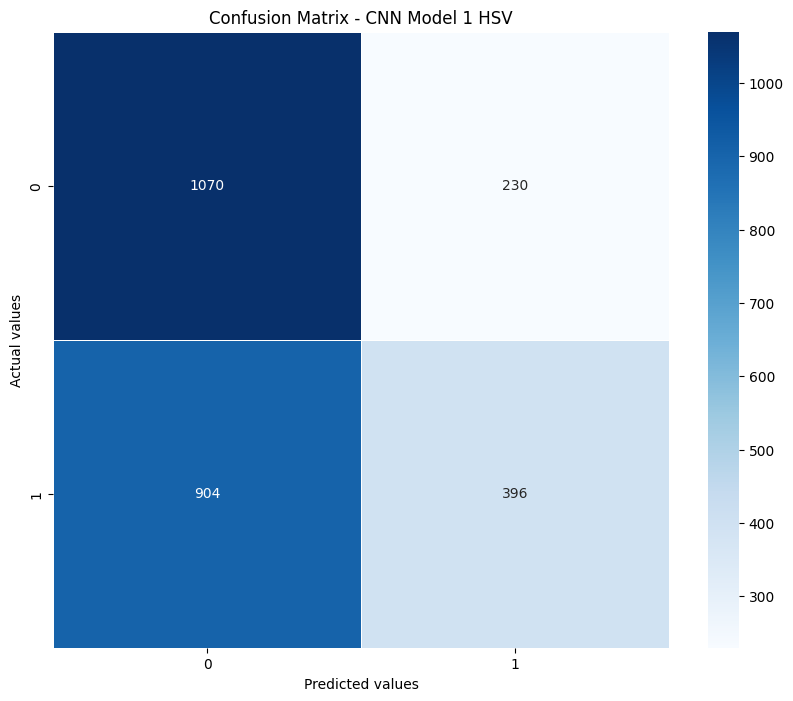

False Negatives (parasitized predicted as uninfected): 904
False Positives (uninfected predicted as parasitized): 230


In [ ]:
# For a detailed explanation of each line of code refer to cnn_model_base confusion matrix

test_pred = cnn_model_1hsv.predict(test_images_norm)

test_pred_arg=np.argmax(test_pred,axis=1)
test_labels_arg=np.argmax(test_labels_encoded,axis=1)

confusion_matrix = tf.math.confusion_matrix(test_labels_arg,test_pred_arg)

f, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt="d",
    square=True,
    ax=ax,
    cmap='Blues'
)
plt.title('Confusion Matrix - CNN Model 1 HSV')
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.show()

# Extracting FN and FP directly from the confusion matrix
# confusion_matrix[actual][predicted]
# FN: parasitized cells predicted as uninfected (actual=1, predicted=0)
# FP: uninfected cells predicted as parasitized (actual=0, predicted=1)
FN_hsv = confusion_matrix[1][0].numpy()
FP_hsv = confusion_matrix[0][1].numpy()
print(f'False Negatives (parasitized predicted as uninfected): {FN_hsv}')
print(f'False Positives (uninfected predicted as parasitized): {FP_hsv}')

In [ ]:
# For a detailed explanation of each line of code refer to cnn_model_base confusion matrix
report_hsv = classification_report(test_labels_arg, test_pred_arg)
print("Test Classification Report:")
print(report_hsv)

Test Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.82      0.65      1300
           1       0.63      0.30      0.41      1300

    accuracy                           0.56      2600
   macro avg       0.59      0.56      0.53      2600
weighted avg       0.59      0.56      0.53      2600



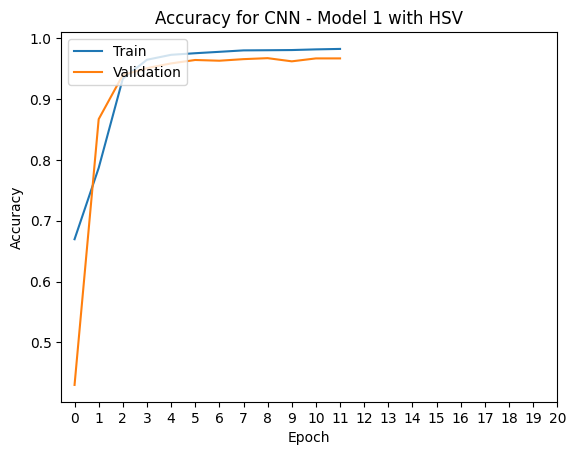

In [ ]:
# Plot training and validation accuracy curves across all 20 epochs
plt.plot(history_hsv.history['accuracy'])
plt.plot(history_hsv.history['val_accuracy'])
plt.title('Accuracy for CNN - Model 1 with HSV')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.xticks(range(0,21))
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

### **Observations and Insights:**

**HSV Model (Model 1 with HSV Images)**

The HSV model applies the same architecture as Model 1 (1,121,426 parameters) but trains on images converted to HSV colour space instead of RGB, achieving a test accuracy of only 56.38%, worse even than the base model trained on RGB images.

The confusion matrix shows 904 False Negatives and 230 False Positives, and the classification report confirms a very poor parasitized recall of 0.30, suggesting that despite the HSV colour space theoretically offering better separation of colour and intensity information (at least visually), it did not provide the model with more discriminative features for this particular task and dataset compared to standard RGB images.